In [4]:
import pandas as pd

df = pd.read_csv('Dados/CSV/PENSE2019_MICRODADOS.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165838 entries, 0 to 165837
Columns: 306 entries, REGIAO to TOTAIS_POSEST
dtypes: float64(296), int64(9), object(1)
memory usage: 387.2+ MB


In [6]:
linhas_com_menos2 = (df == -2).any(axis=1)

total_linhas = linhas_com_menos2.sum()

print("Número de linhas com pelo menos um -2 (Abandono de formulário)", total_linhas)

Número de linhas com pelo menos um -2 (Abandono de formulário) 843


In [7]:
def column_replace(df, column_name, old_value, new_value):
    df[column_name] = df[column_name].replace(old_value, new_value)

In [8]:
def normaliza_coluna(df, column_name):
  df[column_name] = df[column_name] - df[column_name].min()

In [9]:
# Remover linhas que contenham -2 em qualquer coluna
print("Linhas antes:", len(df))

df = df[~(df == -2).any(axis=1)]

print("Linhas depois:", len(df))

Linhas antes: 165838
Linhas depois: 164995


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164995 entries, 0 to 165837
Columns: 306 entries, REGIAO to TOTAIS_POSEST
dtypes: float64(296), int64(9), object(1)
memory usage: 386.5+ MB


In [11]:
df['REGIAO'].value_counts()

REGIAO
2    57886
1    36904
3    29617
5    22816
4    17772
Name: count, dtype: int64

In [12]:
normaliza_coluna(df, 'REGIAO')

In [13]:
mapa_regioes = {
    0: 'Norte',
    1: 'Nordeste',
    2: 'Sudeste',
    3: 'Sul',
    4: 'Centro-Oeste'
}

Região geográfica
Norte           36904
Nordeste        57886
Sudeste         29617
Sul             17772
Centro-Oeste    22816
Name: count, dtype: int64


<AxesSubplot: xlabel='Região geográfica'>

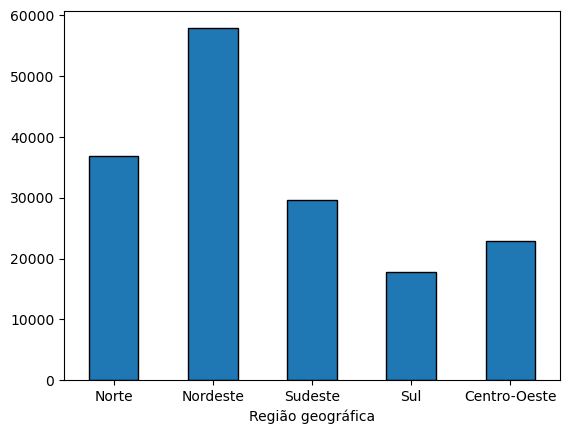

In [14]:
print(df['REGIAO'].rename("Região geográfica").value_counts().sort_index().rename(index=mapa_regioes))
df['REGIAO'].rename("Região geográfica").value_counts().sort_index().rename(index=mapa_regioes).plot(kind='bar', edgecolor='black', rot=0)

In [15]:
df = df.drop(columns=['MUNICIPIO_CAP'])

In [16]:
df['TIPO_MUNIC'].value_counts()

TIPO_MUNIC
1.0    81435
2.0    76967
Name: count, dtype: int64

In [17]:
normaliza_coluna(df, 'TIPO_MUNIC')

In [18]:
mapa_sim_nao = {
    0: 'Sim',
    1: 'Não',
    2: 'Sem resposta'
}

Mora em capital?
Sim    81435
Não    76967
Name: count, dtype: int64


<AxesSubplot: xlabel='Mora em capital?'>

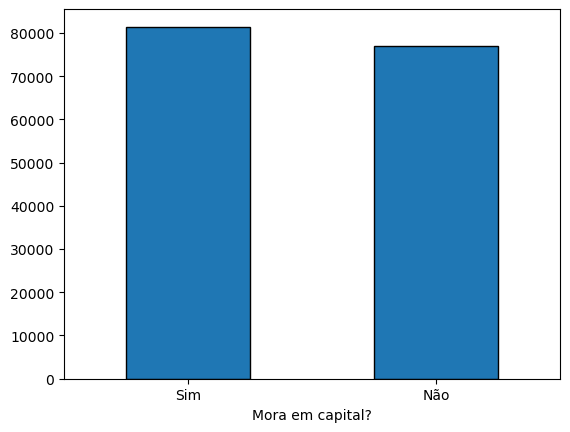

In [19]:
print(df['TIPO_MUNIC'].rename("Mora em capital?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['TIPO_MUNIC'].rename("Mora em capital?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [20]:
df['SITUACAO'].value_counts()

SITUACAO
1.0    150306
2.0      8096
Name: count, dtype: int64

In [21]:
normaliza_coluna(df, 'SITUACAO')

Mora em área urbana?
Sim    150306
Não      8096
Name: count, dtype: int64


<AxesSubplot: xlabel='Mora em área urbana?'>

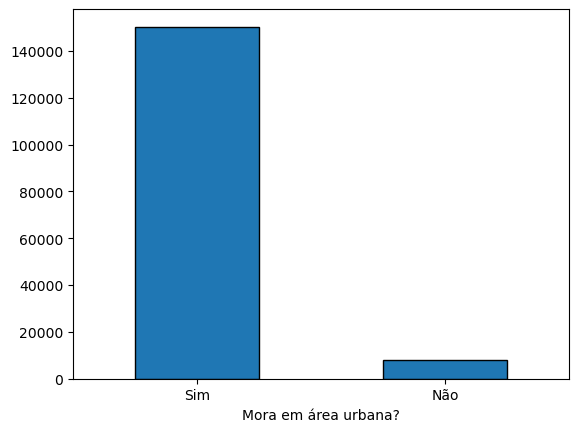

In [22]:
print(df['SITUACAO'].rename("Mora em área urbana?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['SITUACAO'].rename("Mora em área urbana?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [23]:
df['ESFERA'].value_counts()

# Maioria é de escolas privadas

ESFERA
4.0    77531
2.0    62031
3.0    17116
1.0     1724
Name: count, dtype: int64

In [24]:
column_replace(df, 'ESFERA', 4, 0)
column_replace(df, 'ESFERA', 2, 1)
column_replace(df, 'ESFERA', 3, 1)

In [25]:
df['ESFERA'].value_counts()

ESFERA
1.0    80871
0.0    77531
Name: count, dtype: int64

In [26]:
mapa_esfera = {
    0: 'Pública',
    1: 'Privada'    
}

Esfera administrativa
Pública    77531
Privada    80871
Name: count, dtype: int64


<AxesSubplot: xlabel='Esfera administrativa'>

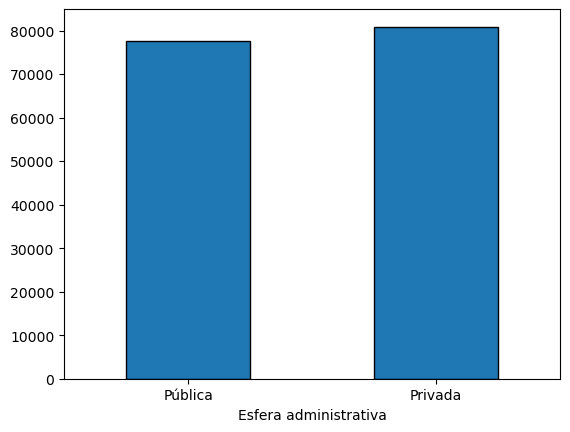

In [27]:
print(df['ESFERA'].rename("Esfera administrativa").value_counts().sort_index().rename(index=mapa_esfera))
df['ESFERA'].rename("Esfera administrativa").value_counts().sort_index().rename(index=mapa_esfera).plot(kind='bar', edgecolor='black', rot=0)

In [28]:
df = df.drop(columns=['ESTRATO', 'IND_EXPANSAO', 'PESO_ALUNO_FREQ', 'PESO_INICIAL', 'POSEST', 'TOTAIS_POSEST', 'ESCOLA', 'TURMA', 'ALUNO'])

In [29]:
df['ANO_TURMA'].value_counts()

ANO_TURMA
1.0     31210
2.0     28931
3.0     27765
4.0     27012
5.0     21199
6.0     19863
7.0      1245
9.0       579
8.0       564
11.0       25
12.0        9
Name: count, dtype: int64

In [30]:
df["ANO_TURMA"] = df["ANO_TURMA"].replace(7, 4)
df["ANO_TURMA"] = df["ANO_TURMA"].replace(10, 4)
df["ANO_TURMA"] = df["ANO_TURMA"].replace(8, 5)
df["ANO_TURMA"] = df["ANO_TURMA"].replace(11, 5)
df["ANO_TURMA"] = df["ANO_TURMA"].replace(9, 6)
df["ANO_TURMA"] = df["ANO_TURMA"].replace(12, 6)

In [31]:
df['ANO_TURMA'].value_counts()

ANO_TURMA
1.0    31210
2.0    28931
4.0    28257
3.0    27765
5.0    21788
6.0    20451
Name: count, dtype: int64

In [32]:
normaliza_coluna(df, 'ANO_TURMA')

In [33]:
mapa_anos_escolares = {
    0: '7º ano',    # Ensino fundamental
    1: '8º ano',
    2: '9º ano',
    3: '1ª série',  # Ensino médio
    4: '2ª série',
    5: '3ª série'
}

Ano escolar
7º ano      31210
8º ano      28931
9º ano      27765
1ª série    28257
2ª série    21788
3ª série    20451
Name: count, dtype: int64


<AxesSubplot: xlabel='Ano escolar'>

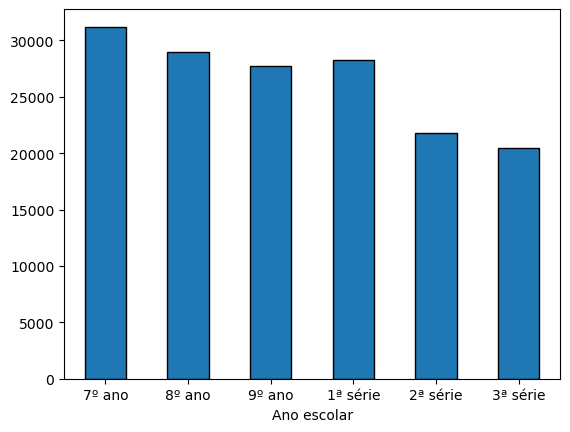

In [34]:
print(df['ANO_TURMA'].rename("Ano escolar").value_counts().sort_index().rename(index=mapa_anos_escolares))
df['ANO_TURMA'].rename("Ano escolar").value_counts().sort_index().rename(index=mapa_anos_escolares).plot(kind='bar', edgecolor='black', rot=0)

In [35]:
df['B00004'].value_counts()

B00004
1.0    158402
Name: count, dtype: int64

In [36]:
df.drop(columns='B00004', inplace=True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164995 entries, 0 to 165837
Columns: 295 entries, REGIAO to E01P27A
dtypes: float64(293), int64(2)
memory usage: 372.6 MB


# INFORMAÇÕES GERAIS

In [38]:
df['B01001A'].value_counts()

B01001A
2.0    80555
1.0    77404
9.0      443
Name: count, dtype: int64

In [39]:
column_replace(df, 'B01001A', 9, 3)
normaliza_coluna(df, 'B01001A')

In [40]:
df['B01001A'].value_counts()

B01001A
1.0    80555
0.0    77404
2.0      443
Name: count, dtype: int64

In [41]:
mapa_sexo = {
    0: 'Homem'    ,
    1: 'Mulher',
    2: 'Sem resposta'    
}

Qual é o seu sexo?
Homem           77404
Mulher          80555
Sem resposta      443
Name: count, dtype: int64


<AxesSubplot: xlabel='Qual é o seu sexo?'>

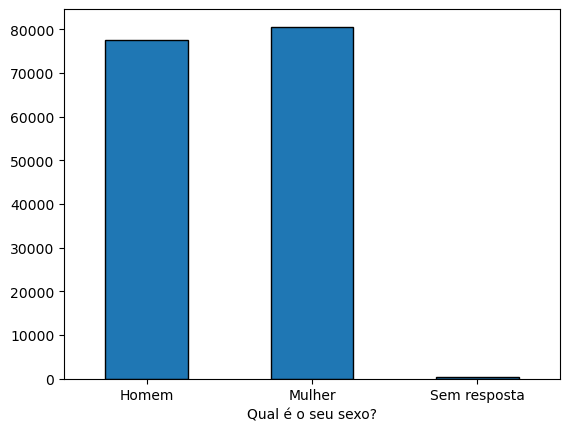

In [42]:
print(df['B01001A'].rename("Qual é o seu sexo?").value_counts().sort_index().rename(index=mapa_sexo))
df['B01001A'].rename("Qual é o seu sexo?").value_counts().sort_index().rename(index=mapa_sexo).plot(kind='bar', edgecolor='black', rot=0)

In [43]:
df['B01003'].value_counts()

B01003
2.0    81952
3.0    42311
1.0    25546
4.0     8167
9.0      426
Name: count, dtype: int64

In [44]:
df = df[df["B01003"] != 9]

In [45]:
normaliza_coluna(df, 'B01003')

In [46]:
df['B01003'].value_counts()

B01003
1.0    81952
2.0    42311
0.0    25546
3.0     8167
Name: count, dtype: int64

In [47]:
mapa_idades = {
    0: '< 13 anos',
    1: '13 a 15 anos',
    2: '16 ou 17 anos',
    3: '18 ou mais'
}

Qual é a sua idade?
< 13 anos        25546
13 a 15 anos     81952
16 ou 17 anos    42311
18 ou mais        8167
Name: count, dtype: int64


<AxesSubplot: xlabel='Qual é a sua idade?'>

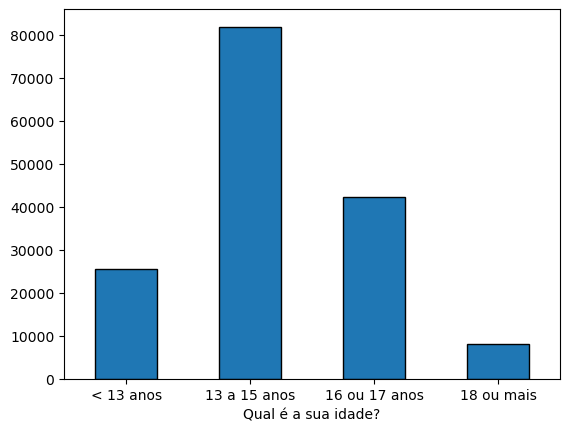

In [48]:
print(df['B01003'].rename("Qual é a sua idade?").value_counts().sort_index().rename(index=mapa_idades))
df['B01003'].rename("Qual é a sua idade?").value_counts().sort_index().rename(index=mapa_idades).plot(kind='bar', edgecolor='black', rot=0)

In [49]:
df['B01004'].value_counts()

B01004
3.0     14638
5.0     14084
4.0     13668
9.0     13263
7.0     13203
6.0     13170
1.0     13047
10.0    12973
8.0     12770
12.0    12463
11.0    12340
2.0     12263
99.0       94
Name: count, dtype: int64

In [50]:
df['B01005'].value_counts()

B01005
2005.0    28102
2004.0    27415
2006.0    26290
2003.0    24838
2002.0    22970
2001.0    12165
2007.0    10707
2000.0     4979
2008.0      333
9999.0      177
Name: count, dtype: int64

In [51]:
df.drop(columns='B01005', inplace=True)

In [52]:
df.drop(columns='B01004', inplace=True)

In [53]:
df.drop(columns='B01021A', inplace=True)

In [54]:
df['B01002'].value_counts()

B01002
4.0    67989
1.0    59917
2.0    16558
3.0     5461
5.0     4696
9.0     3355
Name: count, dtype: int64

In [55]:
column_replace(df,'B01002',9,4)

In [56]:
normaliza_coluna(df, 'B01002')

In [57]:
df['B01002'].value_counts()

B01002
3.0    71344
0.0    59917
1.0    16558
2.0     5461
4.0     4696
Name: count, dtype: int64

In [58]:
mapa_cor_raca = {
    0: 'Branca',
    1: 'Preta',
    2: 'Amarela',
    3: 'Parda',
    4: 'Indígena'
}

Qual é a sua cor ou raça?
Branca     25546
Preta      81952
Amarela    42311
Parda       8167
Name: count, dtype: int64


<AxesSubplot: xlabel='Qual é a sua cor ou raça?'>

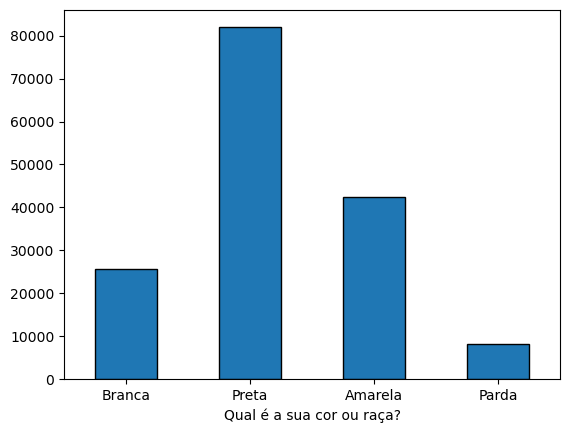

In [59]:
print(df['B01003'].rename("Qual é a sua cor ou raça?").value_counts().sort_index().rename(index=mapa_cor_raca))
df['B01003'].rename("Qual é a sua cor ou raça?").value_counts().sort_index().rename(index=mapa_cor_raca).plot(kind='bar', edgecolor='black', rot=0)

In [60]:
df['B01026A1'].value_counts()

B01026A1
-1.0    70314
 3.0    45076
 1.0    30433
 5.0     6265
 4.0     3276
 2.0     2563
 9.0       49
Name: count, dtype: int64

In [61]:
# colocando pulo em "não sabe"
column_replace(df, 'B01026A1', -1, 5)
column_replace(df, 'B01026A1', 9, 5)

normaliza_coluna(df, 'B01026A1')

In [62]:
df['B01026A1'].value_counts()

B01026A1
4.0    76628
2.0    45076
0.0    30433
3.0     3276
1.0     2563
Name: count, dtype: int64

In [63]:
mapa_planos = {
    0: 'Continuar estudando',
    1: 'Trabalhar apenas',
    2: 'Estudar e trabalhar',
    3: 'Outra coisa',
    4: 'Não sabe'
}

Quando terminar o Ensino Fundamental, você pretende?
Continuar estudando    30433
Trabalhar apenas        2563
Estudar e trabalhar    45076
Outra coisa             3276
Não sabe               76628
Name: count, dtype: int64


<AxesSubplot: xlabel='Quando terminar o Ensino Fundamental, você pretende?'>

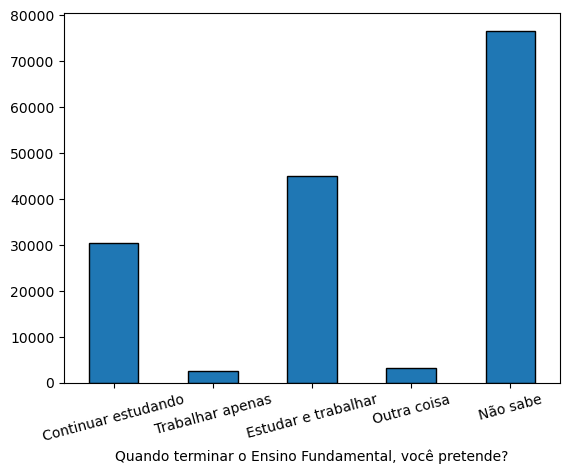

In [64]:
print(df['B01026A1'].rename("Quando terminar o Ensino Fundamental, você pretende?").value_counts().sort_index().rename(index=mapa_planos))
df['B01026A1'].rename("Quando terminar o Ensino Fundamental, você pretende?").value_counts().sort_index().rename(index=mapa_planos).plot(kind='bar', edgecolor='black', rot=15)

In [65]:
df['B01026A2'].value_counts()

B01026A2
 3.0    103985
 1.0     23038
 5.0     11130
 2.0      9979
 4.0      9710
 9.0        82
-1.0        52
Name: count, dtype: int64

In [66]:
# colocando pulo em "não sabe"
column_replace(df, 'B01026A2', -1, 5)
column_replace(df, 'B01026A2', 9, 5)
normaliza_coluna(df, 'B01026A2')

In [67]:
df['B01026A2'].value_counts()

B01026A2
2.0    103985
0.0     23038
4.0     11264
1.0      9979
3.0      9710
Name: count, dtype: int64

Quando terminar o Ensino Médio, você pretende?
Continuar estudando     23038
Trabalhar apenas         9979
Estudar e trabalhar    103985
Outra coisa              9710
Não sabe                11264
Name: count, dtype: int64


<AxesSubplot: xlabel='Quando terminar o Ensino Médio, você pretende?'>

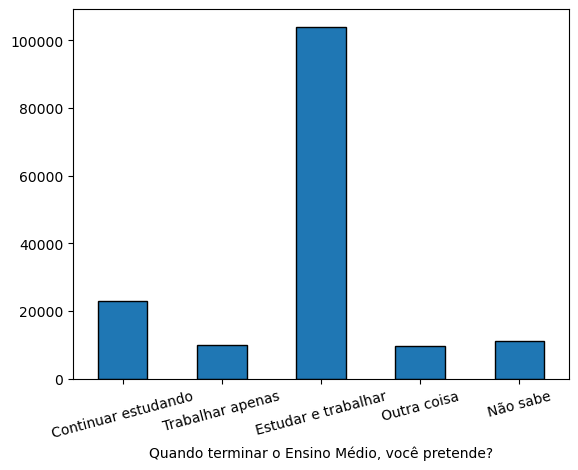

In [68]:
print(df['B01026A2'].rename("Quando terminar o Ensino Médio, você pretende?").value_counts().sort_index().rename(index=mapa_planos))
df['B01026A2'].rename("Quando terminar o Ensino Médio, você pretende?").value_counts().sort_index().rename(index=mapa_planos).plot(kind='bar', edgecolor='black', rot=15)

In [69]:
df['B01006'].value_counts()

B01006
1.0    140433
2.0     17481
9.0        62
Name: count, dtype: int64

In [70]:
column_replace(df, 'B01006', 9, 3)
normaliza_coluna(df, 'B01006')

In [71]:
df['B01006'].value_counts()

B01006
0.0    140433
1.0     17481
2.0        62
Name: count, dtype: int64

Você mora com a sua mãe?
Sim             140433
Não              17481
Sem resposta        62
Name: count, dtype: int64


<AxesSubplot: xlabel='Você mora com a sua mãe?'>

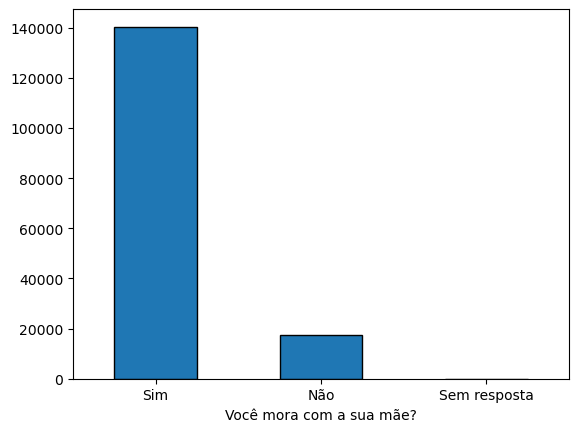

In [72]:
print(df['B01006'].rename("Você mora com a sua mãe?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01006'].rename("Você mora com a sua mãe?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [73]:
df['B01007'].value_counts()

B01007
1.0    100087
2.0     57783
9.0       106
Name: count, dtype: int64

In [74]:
column_replace(df, 'B01007', 9, 3)
normaliza_coluna(df, 'B01007')

In [75]:
df['B01007'].value_counts()

B01007
0.0    100087
1.0     57783
2.0       106
Name: count, dtype: int64

Você mora com o seu pai?
Sim             100087
Não              57783
Sem resposta       106
Name: count, dtype: int64


<AxesSubplot: xlabel='Você mora com o seu pai?'>

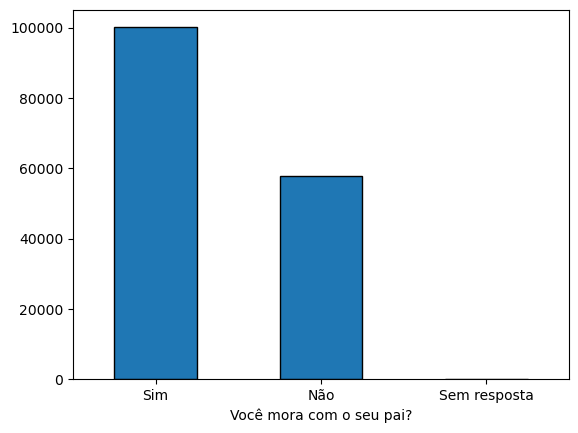

In [76]:
print(df['B01007'].rename("Você mora com o seu pai?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01007'].rename("Você mora com o seu pai?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [77]:
df['B01010A'].value_counts()

B01010A
4.0     56153
3.0     37393
5.0     29701
6.0     11916
2.0     11086
7.0      5484
8.0      2819
9.0      1688
10.0     1316
1.0       323
99.0       97
Name: count, dtype: int64

In [78]:
column_replace(df, 'B01010A', 99, 0)

column_replace(df, 'B01010A', 8, 7)
column_replace(df, 'B01010A', 9, 7)
column_replace(df, 'B01010A', 10, 7)

# 7 - >7

In [79]:
df['B01010A'].value_counts()

B01010A
4.0    56153
3.0    37393
5.0    29701
6.0    11916
7.0    11307
2.0    11086
1.0      323
0.0       97
Name: count, dtype: int64

In [80]:
mapa_qtde_moradia = {
    0: '1 pessoa',
    1: '2 pessoas',
    2: '3 pessoas',
    3: '4 pessoas',
    4: '5 pessoas',
    5: '6 pessoas',
    6: '7 pessoas',
    7: '>7 pessoas'
}

Contando com você, quantas pessoas moram na sua casa ou apartamento?
1 pessoa         97
2 pessoas       323
3 pessoas     11086
4 pessoas     37393
5 pessoas     56153
6 pessoas     29701
7 pessoas     11916
>7 pessoas    11307
Name: count, dtype: int64


<AxesSubplot: xlabel='Contando com você, quantas pessoas moram na sua casa ou apartamento?'>

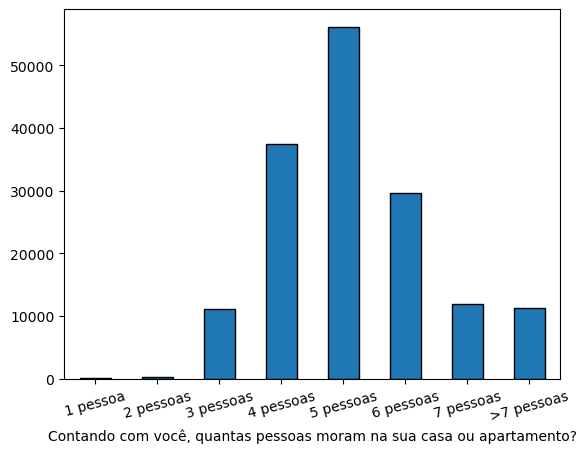

In [81]:
print(df['B01010A'].rename("Contando com você, quantas pessoas moram na sua casa ou apartamento?").value_counts().sort_index().rename(index=mapa_qtde_moradia))
df['B01010A'].rename("Contando com você, quantas pessoas moram na sua casa ou apartamento?").value_counts().sort_index().rename(index=mapa_qtde_moradia).plot(kind='bar', edgecolor='black', rot=15)

In [82]:
df['B01014'].value_counts()

B01014
1.0    137112
2.0     20832
9.0        32
Name: count, dtype: int64

In [83]:
column_replace(df, 'B01014', 9, 2)
normaliza_coluna(df, 'B01014')

Você tem celular?
Sim    137112
Não     20864
Name: count, dtype: int64


<AxesSubplot: xlabel='Você tem celular?'>

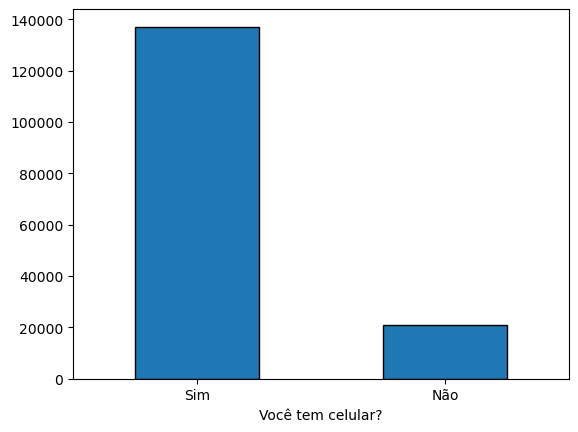

In [84]:
print(df['B01014'].rename("Você tem celular?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01014'].rename("Você tem celular?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [85]:
df['B01015B'].value_counts()

B01015B
1.0    106550
2.0     51376
9.0        50
Name: count, dtype: int64

In [86]:
column_replace(df, 'B01015B', 9, 2)
normaliza_coluna(df, 'B01015B')

Você tem computador?
Sim    106550
Não     51426
Name: count, dtype: int64


<AxesSubplot: xlabel='Você tem computador?'>

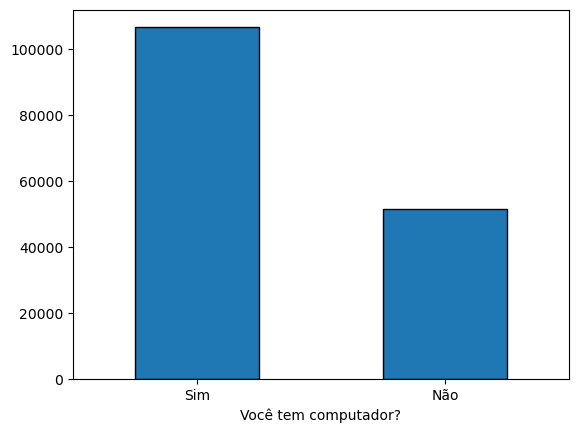

In [87]:
print(df['B01015B'].rename("Você tem computador?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01015B'].rename("Você tem computador?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [88]:
df['B01016'].value_counts()

B01016
1.0    143370
2.0     14564
9.0        42
Name: count, dtype: int64

In [89]:
column_replace(df, 'B01016', 9, 2)
normaliza_coluna(df, 'B01016')

Você tem acesso à internet em casa?
Sim    143370
Não     14606
Name: count, dtype: int64


<AxesSubplot: xlabel='Você tem acesso à internet em casa?'>

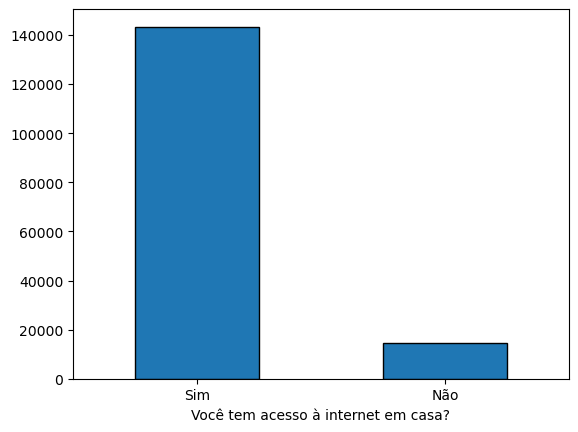

In [90]:
print(df['B01016'].rename("Você tem acesso à internet em casa?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01016'].rename("Você tem acesso à internet em casa?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [91]:
df['B01017'].value_counts()

B01017
1.0    104624
2.0     53301
9.0        51
Name: count, dtype: int64

In [92]:
column_replace(df, 'B01017', 9, 2)
normaliza_coluna(df, 'B01017')

Alguém da sua casa tem carro?
Sim    104624
Não     53352
Name: count, dtype: int64


<AxesSubplot: xlabel='Alguém da sua casa tem carro?'>

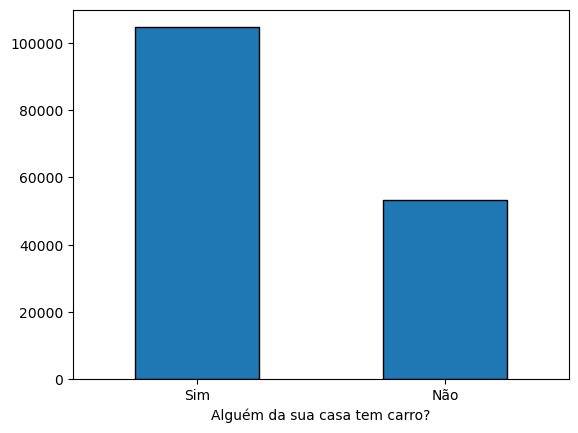

In [93]:
print(df['B01017'].rename("Alguém da sua casa tem carro?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01017'].rename("Alguém da sua casa tem carro?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [94]:
df['B01018A'].value_counts()

B01018A
2.0    98854
1.0    59071
9.0       51
Name: count, dtype: int64

In [95]:
column_replace(df, 'B01018A', 9, 2)
normaliza_coluna(df, 'B01018A')

Alguém da sua casa tem motocicleta?
Sim    59071
Não    98905
Name: count, dtype: int64


<AxesSubplot: xlabel='Alguém da sua casa tem motocicleta?'>

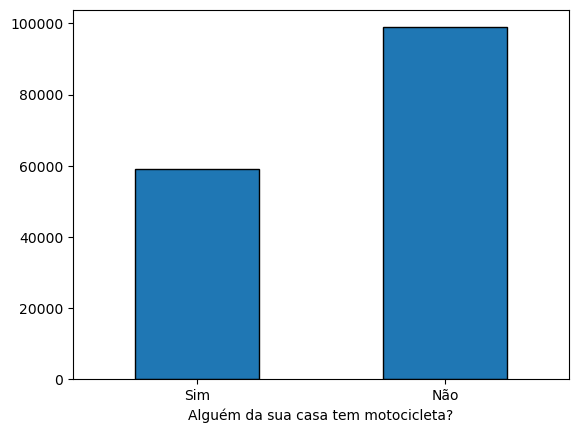

In [96]:
print(df['B01018A'].rename("Alguém da sua casa tem motocicleta?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01018A'].rename("Alguém da sua casa tem motocicleta?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [97]:
df['B01019A'].value_counts()

B01019A
2.0    71780
3.0    51803
4.0    19843
5.0    11841
1.0     2625
9.0       84
Name: count, dtype: int64

In [98]:
column_replace(df, 'B01019A',9, 1)
normaliza_coluna(df, 'B01019A')

In [99]:
df['B01019A'].value_counts()

B01019A
1.0    71780
2.0    51803
3.0    19843
4.0    11841
0.0     2709
Name: count, dtype: int64

In [100]:
mapa_banheiros = {
    0: 'Sem banheiro',
    1: '1 banheiro',
    2: '2 banheiros',
    3: '3 banheiros',
    4: '> 3 banheiros'    
}

Quantos banheiros tem na sua casa?
Sem banheiro      2709
1 banheiro       71780
2 banheiros      51803
3 banheiros      19843
> 3 banheiros    11841
Name: count, dtype: int64


<AxesSubplot: xlabel='Quantos banheiros tem na sua casa?'>

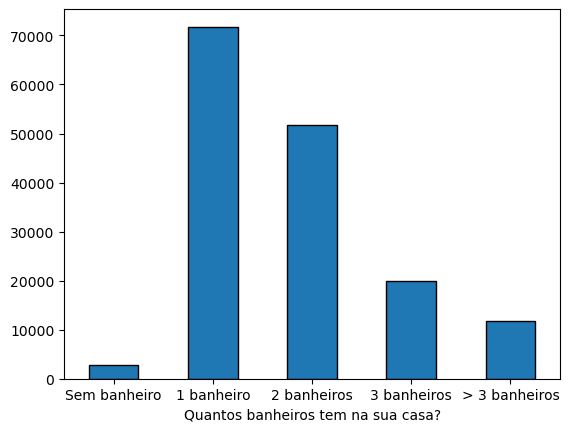

In [101]:
print(df['B01019A'].rename("Quantos banheiros tem na sua casa?").value_counts().sort_index().rename(index=mapa_banheiros))
df['B01019A'].rename("Quantos banheiros tem na sua casa?").value_counts().sort_index().rename(index=mapa_banheiros).plot(kind='bar', edgecolor='black', rot=0)

In [102]:
df['B01020A'].value_counts()

B01020A
2.0    130010
1.0     27834
9.0       132
Name: count, dtype: int64

In [103]:
column_replace(df, 'B01020A', 9, 2)
normaliza_coluna(df, 'B01020A')

Tem empregada doméstica?
Sim     27834
Não    130142
Name: count, dtype: int64


<AxesSubplot: xlabel='Tem empregada doméstica?'>

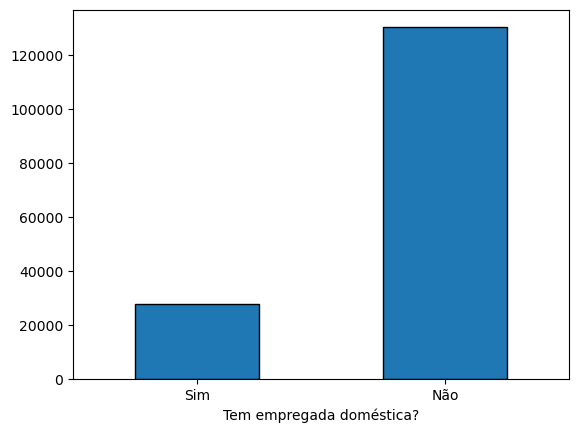

In [104]:
print(df['B01020A'].rename("Tem empregada doméstica?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B01020A'].rename("Tem empregada doméstica?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [105]:
df['B01008B'].value_counts()

B01008B
7.0    50578
5.0    28992
8.0    27330
2.0    18418
6.0    11351
4.0     9407
3.0     7169
1.0     4443
9.0      288
Name: count, dtype: int64

In [106]:
column_replace(df, 'B01008B', 9,8)
normaliza_coluna(df, 'B01008B')

In [107]:
mapa_inst_mae = {
    0: 'Sem estudos',
    1: 'Fundamental incompleto',
    2: 'Fundamental completo',
    3: 'Médio incompleto',
    4: 'Médio completo',
    5: 'Superior incompleto',
    6: 'Superior completo',
    7: 'Não sei'
}

Qual nível de instrução da sua mãe?
Sem estudos                4443
Fundamental incompleto    18418
Fundamental completo       7169
Médio incompleto           9407
Médio completo            28992
Superior incompleto       11351
Superior completo         50578
Não sei                   27618
Name: count, dtype: int64


<AxesSubplot: xlabel='Qual nível de instrução da sua mãe?'>

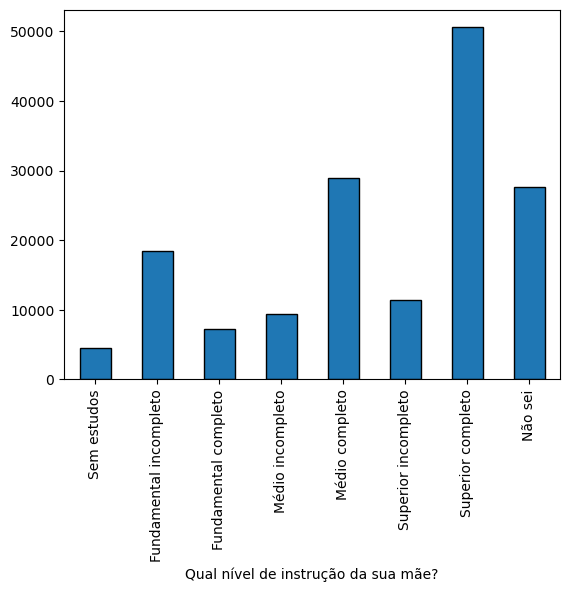

In [108]:
print(df['B01008B'].rename("Qual nível de instrução da sua mãe?").value_counts().sort_index().rename(index=mapa_inst_mae))
df['B01008B'].rename("Qual nível de instrução da sua mãe?").value_counts().sort_index().rename(index=mapa_inst_mae).plot(kind='bar', edgecolor='black', rot=90)

# ALIMENTAÇÃO

In [109]:
df['B02019A'].value_counts()

B02019A
1.0    89139
5.0    34639
6.0    15063
3.0     6802
2.0     6719
4.0     5575
9.0       39
Name: count, dtype: int64

In [110]:
column_replace(df, 'B02019A', 9, 6)
normaliza_coluna(df, 'B02019A')

In [111]:
column_replace(df, 'B02019A', 1, 0)
column_replace(df, 'B02019A', 2, 0)
column_replace(df, 'B02019A', 3, 0)

In [112]:
column_replace(df, 'B02019A', 4, 1)
column_replace(df, 'B02019A', 5, 2)

In [113]:
df['B02019A'].value_counts()

B02019A
0.0    108235
1.0     34639
2.0     15102
Name: count, dtype: int64

In [114]:
mapa_freq_ref = {
    0: 'Sim',
    1: 'Raramente',
    2: 'Não',
    3: 'Sem resposta'
}

Você costuma tomar café da manhã?
Sim          108235
Raramente     34639
Não           15102
Name: count, dtype: int64


<AxesSubplot: xlabel='Você costuma tomar café da manhã?'>

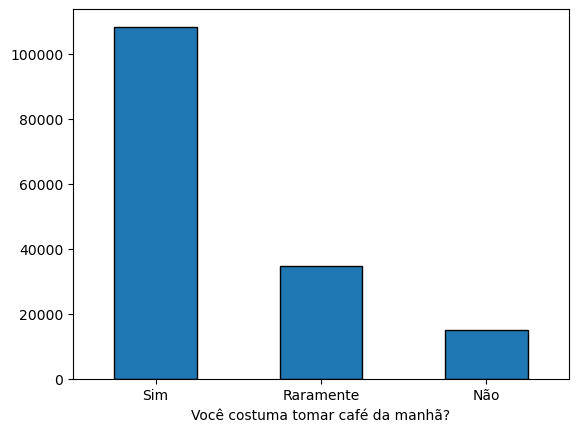

In [115]:
print(df['B02019A'].rename("Você costuma tomar café da manhã?").value_counts().sort_index().rename(index=mapa_freq_ref))
df['B02019A'].rename("Você costuma tomar café da manhã?").value_counts().sort_index().rename(index=mapa_freq_ref).plot(kind='bar', edgecolor='black', rot=0)

In [116]:
df['B02017A'].value_counts()

B02017A
1.0    97879
5.0    22884
6.0    10672
3.0     9298
2.0     8743
4.0     8426
9.0       74
Name: count, dtype: int64

In [117]:
column_replace(df, 'B02017A', 9, 6)
normaliza_coluna(df, 'B02017A')

In [118]:
column_replace(df, 'B02017A', 1, 0)
column_replace(df, 'B02017A', 2, 0)
column_replace(df, 'B02017A', 3, 0)

In [119]:
column_replace(df, 'B02017A', 4, 1)
column_replace(df, 'B02017A', 5, 2)

Você costuma almoçar ou jantar com responsáveis?
Sim          124346
Raramente     22884
Não           10746
Name: count, dtype: int64


<AxesSubplot: xlabel='Você costuma almoçar ou jantar com responsáveis?'>

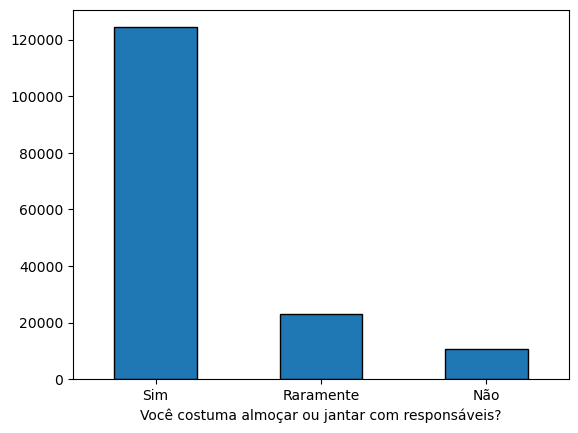

In [120]:
print(df['B02017A'].rename("Você costuma almoçar ou jantar com responsáveis?").value_counts().sort_index().rename(index=mapa_freq_ref))
df['B02017A'].rename("Você costuma almoçar ou jantar com responsáveis?").value_counts().sort_index().rename(index=mapa_freq_ref).plot(kind='bar', edgecolor='black', rot=0)

In [121]:
df['B02018B'].value_counts()

B02018B
1.0    73085
5.0    43946
4.0    15093
3.0    13920
2.0    11776
9.0      156
Name: count, dtype: int64

In [122]:
column_replace(df, 'B02018B', 9, 5)
column_replace(df, 'B02018B', 2, 1)
column_replace(df, 'B02018B', 3, 1)
column_replace(df, 'B02018B', 4, 1)
normaliza_coluna(df, 'B02018B')
column_replace(df, 'B02018B', 4, 1)


Você costuma comer enquanto faz outras coisas?
Sim    113874
Não     44102
Name: count, dtype: int64


<AxesSubplot: xlabel='Você costuma comer enquanto faz outras coisas?'>

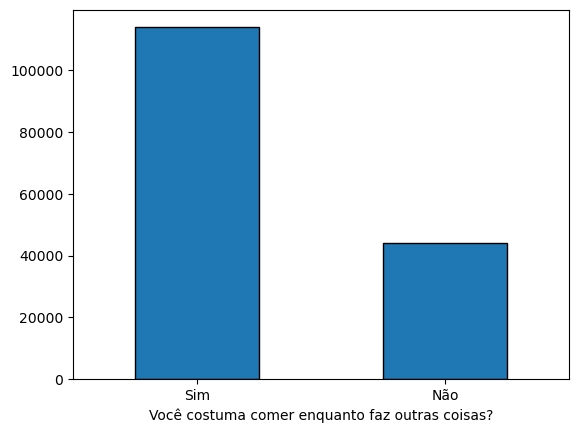

In [123]:
print(df['B02018B'].rename("Você costuma comer enquanto faz outras coisas?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02018B'].rename("Você costuma comer enquanto faz outras coisas?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [124]:
df['B02028'].value_counts()

B02028
2.0    94025
1.0    63898
9.0       53
Name: count, dtype: int64

In [125]:
column_replace(df, 'B02028', 9, 2)
normaliza_coluna(df, 'B02028')

Tomou refrigerante recentemente?
Sim    63898
Não    94078
Name: count, dtype: int64


<AxesSubplot: xlabel='Tomou refrigerante recentemente?'>

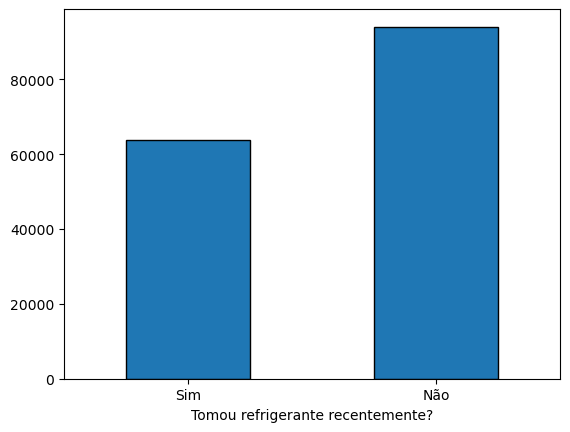

In [126]:
print(df['B02028'].rename("Tomou refrigerante recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02028'].rename("Tomou refrigerante recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [127]:
df['B02029'].value_counts()

B02029
2.0    118382
1.0     39500
9.0        94
Name: count, dtype: int64

In [128]:
column_replace(df, 'B02029', 9, 2)
normaliza_coluna(df, 'B02029')

Tomou suco recentemente?
Sim     39500
Não    118476
Name: count, dtype: int64


<AxesSubplot: xlabel='Tomou suco recentemente?'>

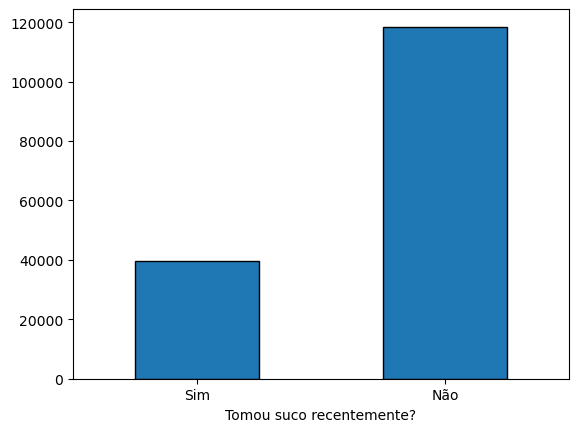

In [129]:
print(df['B02029'].rename("Tomou suco recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02029'].rename("Tomou suco recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [130]:
df['B02030'].value_counts()

B02030
2.0    129469
1.0     28382
9.0       125
Name: count, dtype: int64

In [131]:
column_replace(df, 'B02030', 9, 2)
normaliza_coluna(df, 'B02030')

Tomou refresco recentemente?
Sim     28382
Não    129594
Name: count, dtype: int64


<AxesSubplot: xlabel='Tomou refresco recentemente?'>

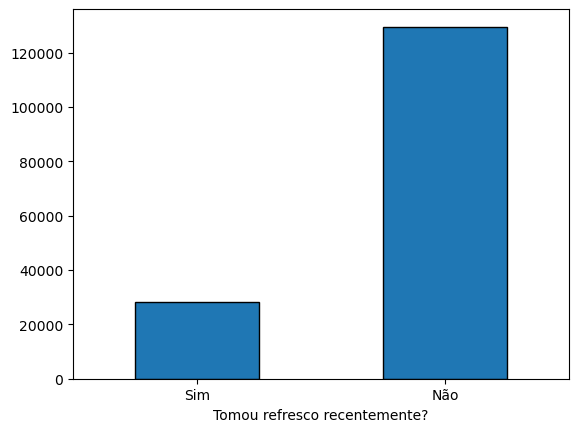

In [132]:
print(df['B02030'].rename("Tomou refresco recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02030'].rename("Tomou refresco recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [133]:
df['B02031'].value_counts()

B02031
2.0    115091
1.0     42792
9.0        93
Name: count, dtype: int64

In [134]:
column_replace(df, 'B02031', 9, 2)
normaliza_coluna(df, 'B02031')

Tomou achocolatado recentemente?
Sim     42792
Não    115184
Name: count, dtype: int64


<AxesSubplot: xlabel='Tomou achocolatado recentemente?'>

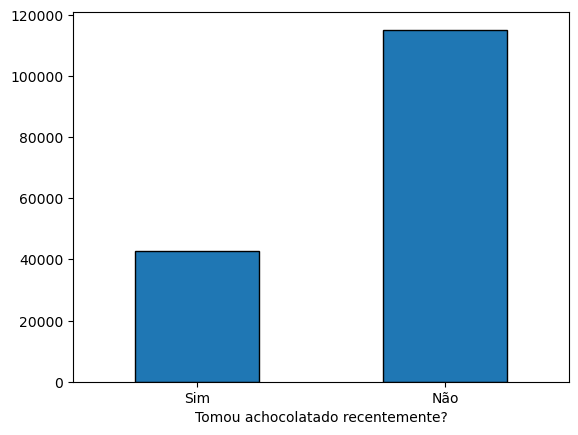

In [135]:
print(df['B02031'].rename("Tomou achocolatado recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02031'].rename("Tomou achocolatado recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [136]:
df['B02032'].value_counts()

B02032
2.0    131693
1.0     26179
9.0       104
Name: count, dtype: int64

In [137]:
column_replace(df, 'B02032', 9, 2)
normaliza_coluna(df, 'B02032')

Tomou iogurte recentemente?
Sim     26179
Não    131797
Name: count, dtype: int64


<AxesSubplot: xlabel='Tomou iogurte recentemente?'>

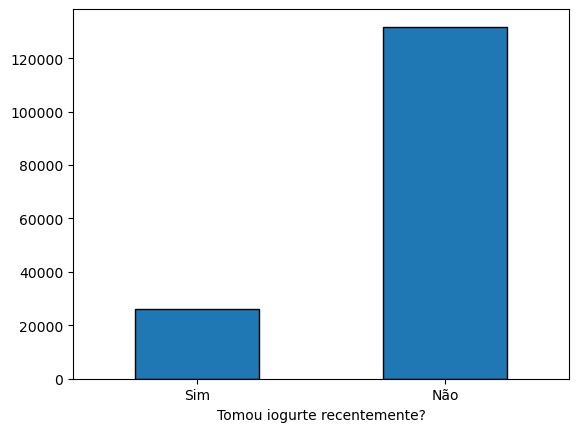

In [138]:
print(df['B02032'].rename("Tomou iogurte recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02032'].rename("Tomou iogurte recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [139]:
df['B02033'].value_counts()

B02033
2.0    82579
1.0    75278
9.0      119
Name: count, dtype: int64

In [140]:
column_replace(df, 'B02033', 9, 2)
normaliza_coluna(df, 'B02033')

Comeu salgadinho ou bolacha salgada recentemente?
Sim    75278
Não    82698
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu salgadinho ou bolacha salgada recentemente?'>

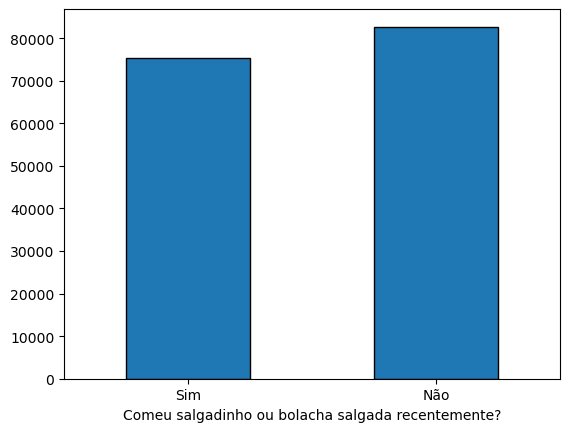

In [141]:
print(df['B02033'].rename("Comeu salgadinho ou bolacha salgada recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02033'].rename("Comeu salgadinho ou bolacha salgada recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [142]:
df['B02034'].value_counts()

B02034
2.0    87421
1.0    70425
9.0      130
Name: count, dtype: int64

In [143]:
column_replace(df, 'B02034', 9, 2)
normaliza_coluna(df, 'B02034')

Comeu bolacha doce/recheada recentemente?
Sim    70425
Não    87551
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu bolacha doce/recheada recentemente?'>

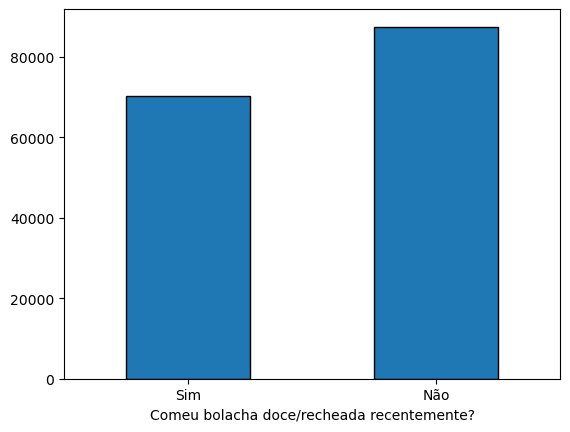

In [144]:
print(df['B02034'].rename("Comeu bolacha doce/recheada recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02034'].rename("Comeu bolacha doce/recheada recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [145]:
df['B02035'].value_counts()

B02035
2.0    100507
1.0     57336
9.0       133
Name: count, dtype: int64

In [146]:
column_replace(df, 'B02035', 9, 2)
normaliza_coluna(df, 'B02035')

Comeu sobremesa recentemente?
Sim     57336
Não    100640
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu sobremesa recentemente?'>

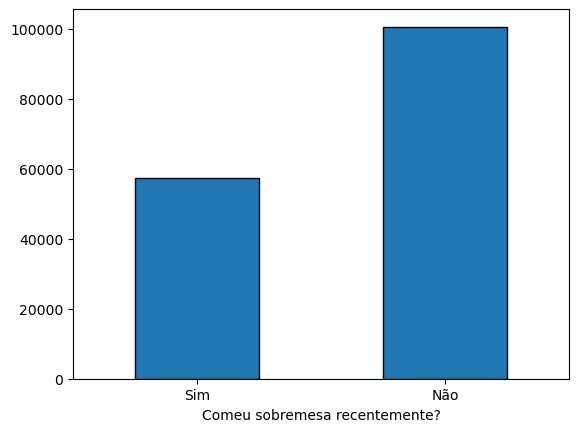

In [147]:
print(df['B02035'].rename("Comeu sobremesa recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02035'].rename("Comeu sobremesa recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [148]:
df['B02036'].value_counts()

B02036
2.0    96939
1.0    60918
9.0      119
Name: count, dtype: int64

In [149]:
column_replace(df, 'B02036', 9, 2)
normaliza_coluna(df, 'B02036')

Comeu salsicha/linguiça/presunto recentemente?
Sim    60918
Não    97058
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu salsicha/linguiça/presunto recentemente?'>

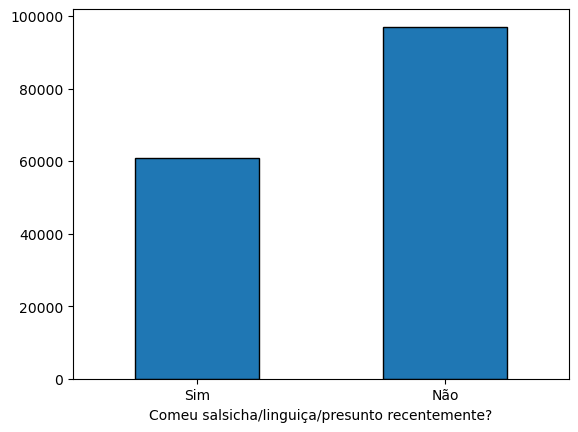

In [150]:
print(df['B02036'].rename("Comeu salsicha/linguiça/presunto recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02036'].rename("Comeu salsicha/linguiça/presunto recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [151]:
df['B02037'].value_counts()

B02037
2.0    88427
1.0    69428
9.0      121
Name: count, dtype: int64

In [152]:
column_replace(df, 'B02037', 9, 2)
normaliza_coluna(df, 'B02037')

Comeu pão de forma recentemente?
Sim    69428
Não    88548
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu pão de forma recentemente?'>

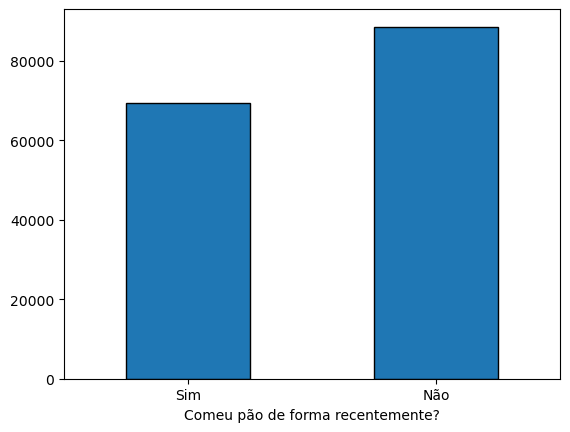

In [153]:
print(df['B02037'].rename("Comeu pão de forma recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02037'].rename("Comeu pão de forma recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [154]:
df['B02038'].value_counts()

B02038
2.0    95642
1.0    62208
9.0      126
Name: count, dtype: int64

In [155]:
column_replace(df, 'B02038', 9, 2)
normaliza_coluna(df, 'B02038')

Comeu margarina recentemente?
Sim    62208
Não    95768
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu margarina recentemente?'>

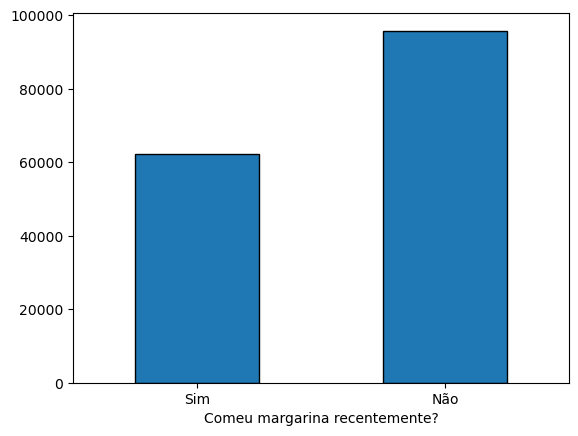

In [156]:
print(df['B02038'].rename("Comeu margarina recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02038'].rename("Comeu margarina recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [157]:
df['B02039'].value_counts()

B02039
2.0    109624
1.0     48239
9.0       113
Name: count, dtype: int64

In [158]:
column_replace(df, 'B02039', 9, 2)
normaliza_coluna(df, 'B02039')

Comeu maionese/molho industrializado recentemente?
Sim     48239
Não    109737
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu maionese/molho industrializado recentemente?'>

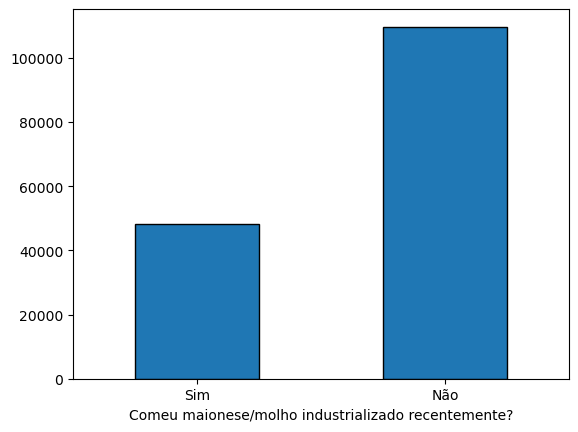

In [159]:
print(df['B02039'].rename("Comeu maionese/molho industrializado recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02039'].rename("Comeu maionese/molho industrializado recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [160]:
df['B02040'].value_counts()

B02040
2.0    129037
1.0     28773
9.0       166
Name: count, dtype: int64

In [161]:
column_replace(df, 'B02040', 9, 2)
normaliza_coluna(df, 'B02040')

Comeu macarrão instantêneo e/ou pratos congelados recentemente?
Sim     28773
Não    129203
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu macarrão instantêneo e/ou pratos congelados recentemente?'>

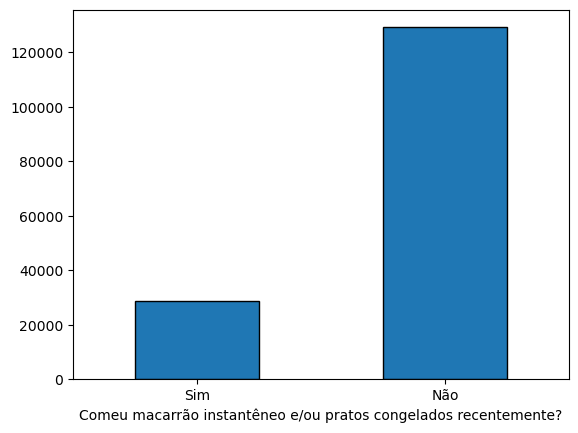

In [162]:
print(df['B02040'].rename("Comeu macarrão instantêneo e/ou pratos congelados recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02040'].rename("Comeu macarrão instantêneo e/ou pratos congelados recentemente?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [163]:
df['B02001'].value_counts()

B02001
8.0    58582
1.0    20266
4.0    16674
5.0    14960
6.0    14578
3.0    13112
7.0     9813
2.0     9807
9.0      184
Name: count, dtype: int64

In [164]:
# Comeu de 1 - 3 dias
column_replace(df, 'B02001', 3, 2)
column_replace(df, 'B02001', 4, 2)

# Comeu de 4 - 7 dias
column_replace(df, 'B02001', 5, 3)
column_replace(df, 'B02001', 6, 3)
column_replace(df, 'B02001', 7, 3)
column_replace(df, 'B02001', 8, 3)

# Não comeu
column_replace(df, 'B02001', 9, 1)

normaliza_coluna(df, 'B02001')

In [165]:
mapa_freq_pratos = {
    0: 'Não',
    1: 'Entre 1 a 3 dias',
    2: 'Entre 4 a 7 dias'
}

Comeu feijão com que frequência nos últimos 7 dias
Não                 20450
Entre 1 a 3 dias    39593
Entre 4 a 7 dias    97933
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu feijão com que frequência nos últimos 7 dias'>

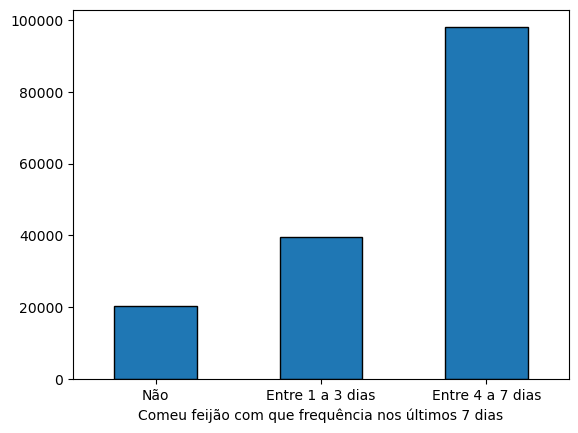

In [166]:
print(df['B02001'].rename("Comeu feijão com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos))
df['B02001'].rename("Comeu feijão com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos).plot(kind='bar', edgecolor='black', rot=0)

In [167]:
df['B02004B'].value_counts()

B02004B
1.0    40110
8.0    33941
4.0    19261
3.0    17865
2.0    15580
5.0    14428
6.0    11073
7.0     5492
9.0      226
Name: count, dtype: int64

In [168]:
# Comeu de 1 - 3 dias
column_replace(df, 'B02004B', 3, 2)
column_replace(df, 'B02004B', 4, 2)

# Comeu de 4 - 7 dias
column_replace(df, 'B02004B', 5, 3)
column_replace(df, 'B02004B', 6, 3)
column_replace(df, 'B02004B', 7, 3)
column_replace(df, 'B02004B', 8, 3)

# Não comeu
column_replace(df, 'B02004B', 9, 1)

normaliza_coluna(df, 'B02004B')

Comeu verduras com que frequência nos últimos 7 dias
Não                 40336
Entre 1 a 3 dias    52706
Entre 4 a 7 dias    64934
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu verduras com que frequência nos últimos 7 dias'>

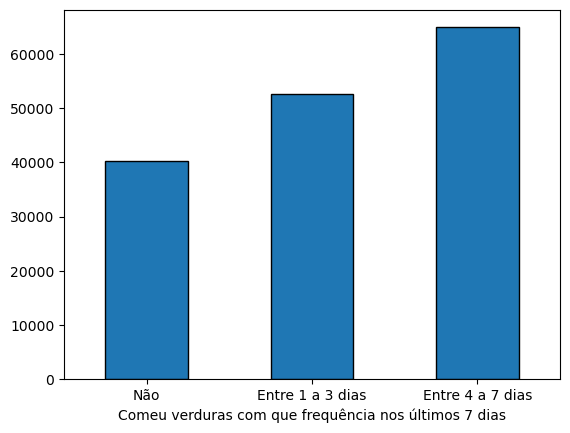

In [169]:
print(df['B02004B'].rename("Comeu verduras com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos))
df['B02004B'].rename("Comeu verduras com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos).plot(kind='bar', edgecolor='black', rot=0)

In [170]:
df['B02010A'].value_counts()

B02010A
8.0    30059
3.0    24790
4.0    24194
2.0    21873
1.0    19381
5.0    17013
6.0    13519
7.0     6915
9.0      232
Name: count, dtype: int64

In [171]:
# Comeu de 1 - 3 dias
column_replace(df, 'B02010A', 3, 2)
column_replace(df, 'B02010A', 4, 2)

# Comeu de 4 - 7 dias
column_replace(df, 'B02010A', 5, 3)
column_replace(df, 'B02010A', 6, 3)
column_replace(df, 'B02010A', 7, 3)
column_replace(df, 'B02010A', 8, 3)

# Não comeu
column_replace(df, 'B02010A', 9, 1)

normaliza_coluna(df, 'B02010A')

Comeu doces com que frequência nos últimos 7 dias
Não                 19613
Entre 1 a 3 dias    70857
Entre 4 a 7 dias    67506
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu doces com que frequência nos últimos 7 dias'>

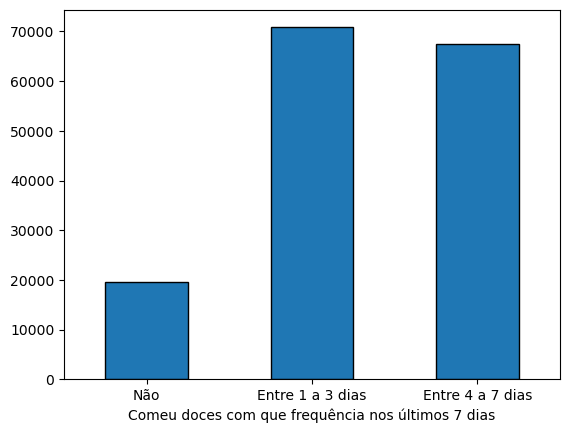

In [172]:
print(df['B02010A'].rename("Comeu doces com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos))
df['B02010A'].rename("Comeu doces com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos).plot(kind='bar', edgecolor='black', rot=0)

In [173]:
df['B02011'].value_counts()

B02011
1.0    41784
8.0    27959
3.0    19367
4.0    18995
2.0    18111
5.0    14369
6.0    11246
7.0     5913
9.0      232
Name: count, dtype: int64

In [174]:
# Comeu de 1 - 3 dias
column_replace(df, 'B02011', 3, 2)
column_replace(df, 'B02011', 4, 2)

# Comeu de 4 - 7 dias
column_replace(df, 'B02011', 5, 3)
column_replace(df, 'B02011', 6, 3)
column_replace(df, 'B02011', 7, 3)
column_replace(df, 'B02011', 8, 3)

# Não comeu
column_replace(df, 'B02011', 9, 1)

normaliza_coluna(df, 'B02011')

Comeu frutas com que frequência nos últimos 7 dias
Não                 42016
Entre 1 a 3 dias    56473
Entre 4 a 7 dias    59487
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu frutas com que frequência nos últimos 7 dias'>

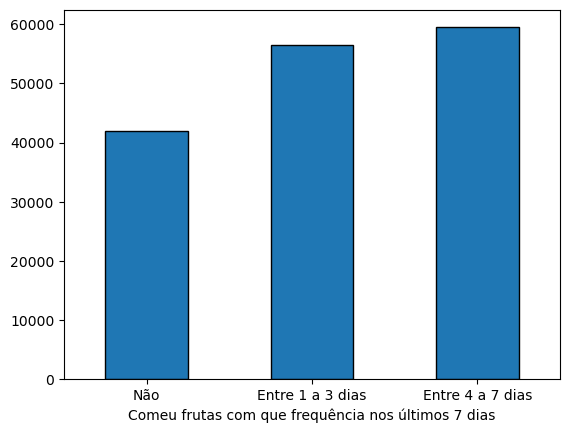

In [175]:
print(df['B02011'].rename("Comeu frutas com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos))
df['B02011'].rename("Comeu frutas com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos).plot(kind='bar', edgecolor='black', rot=0)

In [176]:
df['B02013'].value_counts()

B02013
1.0    42400
2.0    28680
3.0    27876
4.0    20991
5.0    12852
8.0    12318
6.0     8410
7.0     4283
9.0      166
Name: count, dtype: int64

In [177]:
# Comeu de 1 - 3 dias
column_replace(df, 'B02013', 3, 2)
column_replace(df, 'B02013', 4, 2)

# Comeu de 4 - 7 dias
column_replace(df, 'B02013', 5, 3)
column_replace(df, 'B02013', 6, 3)
column_replace(df, 'B02013', 7, 3)
column_replace(df, 'B02013', 8, 3)

# Não comeu
column_replace(df, 'B02013', 9, 1)

normaliza_coluna(df, 'B02013')

Tomou refrigerante com que frequência nos últimos 7 dias
Não                 42566
Entre 1 a 3 dias    77547
Entre 4 a 7 dias    37863
Name: count, dtype: int64


<AxesSubplot: xlabel='Tomou refrigerante com que frequência nos últimos 7 dias'>

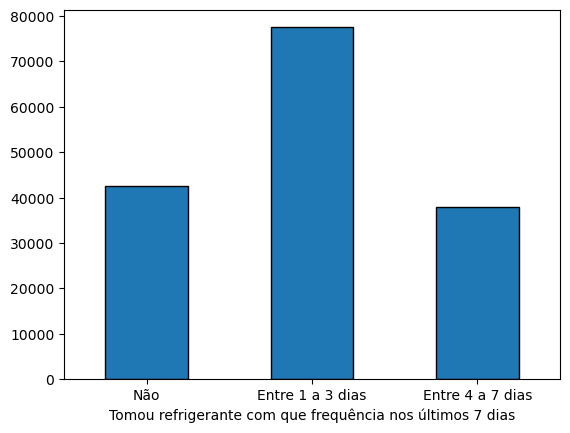

In [178]:
print(df['B02013'].rename("Tomou refrigerante com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos))
df['B02013'].rename("Tomou refrigerante com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos).plot(kind='bar', edgecolor='black', rot=0)

In [179]:
df['B02023A'].value_counts()

B02023A
1.0    75085
2.0    35021
3.0    20305
4.0    11456
5.0     6181
6.0     3966
8.0     3563
7.0     2161
9.0      238
Name: count, dtype: int64

In [180]:
# Comeu de 1 - 3 dias
column_replace(df, 'B02023A', 3, 2)
column_replace(df, 'B02023A', 4, 2)

# Comeu de 4 - 7 dias
column_replace(df, 'B02023A', 5, 3)
column_replace(df, 'B02023A', 6, 3)
column_replace(df, 'B02023A', 7, 3)
column_replace(df, 'B02023A', 8, 3)

# Não comeu
column_replace(df, 'B02023A', 9, 1)

normaliza_coluna(df, 'B02023A')

Comeu em lanchonetes com que frequência nos últimos 7 dias
Não                 75323
Entre 1 a 3 dias    66782
Entre 4 a 7 dias    15871
Name: count, dtype: int64


<AxesSubplot: xlabel='Comeu em lanchonetes com que frequência nos últimos 7 dias'>

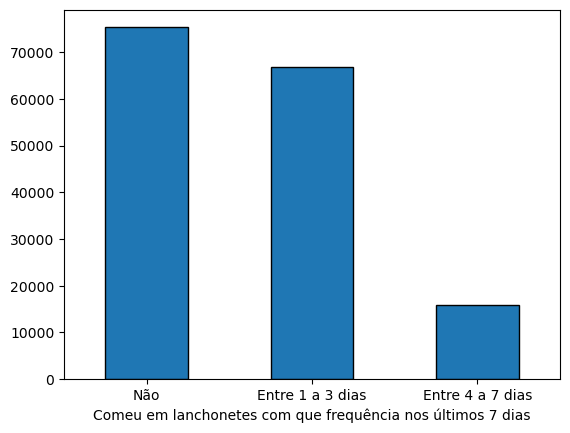

In [181]:
print(df['B02023A'].rename("Comeu em lanchonetes com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos))
df['B02023A'].rename("Comeu em lanchonetes com que frequência nos últimos 7 dias").value_counts().sort_index().rename(index=mapa_freq_pratos).plot(kind='bar', edgecolor='black', rot=0)

In [182]:
df['B02021A'].value_counts()

B02021A
1.0    76325
2.0    69726
3.0    11752
9.0      173
Name: count, dtype: int64

In [183]:
column_replace(df, 'B02021A', 9, 3)
normaliza_coluna(df, 'B02021A')

Sua escola oferece merenda?
Sim             76325
Não             69726
Sem resposta    11925
Name: count, dtype: int64


<AxesSubplot: xlabel='Sua escola oferece merenda?'>

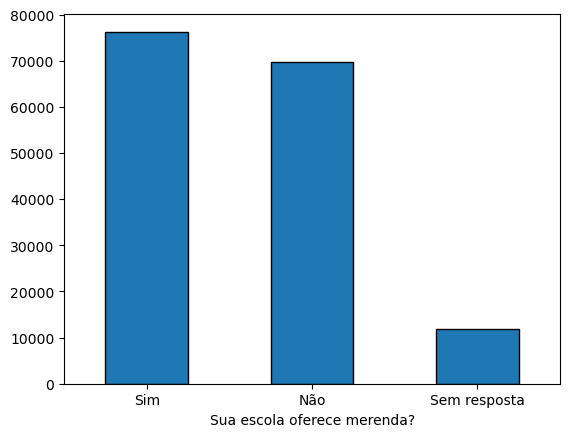

In [184]:
print(df['B02021A'].rename("Sua escola oferece merenda?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B02021A'].rename("Sua escola oferece merenda?").value_counts().sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [185]:
df['B02020B'].value_counts()

B02020B
-1.0    81651
 1.0    24156
 4.0    20586
 5.0    15724
 2.0     9531
 3.0     6276
 9.0       52
Name: count, dtype: int64

In [186]:
# sim
column_replace(df, 'B02020B', 1, 0)
column_replace(df, 'B02020B', 2, 0)
column_replace(df, 'B02020B', 3, 0)

# raramente
column_replace(df, 'B02020B', 4, 1)

# nao
column_replace(df, 'B02020B', 5, 2)

# sem resposta (sem merenda)
column_replace(df, 'B02020B', -1, 3)
column_replace(df, 'B02020B', 9, 3)

Você come a merenda oferecida pela escola?
Sim          39963
Raramente    20586
Não          15724
Name: count, dtype: int64


<AxesSubplot: xlabel='Você come a merenda oferecida pela escola?'>

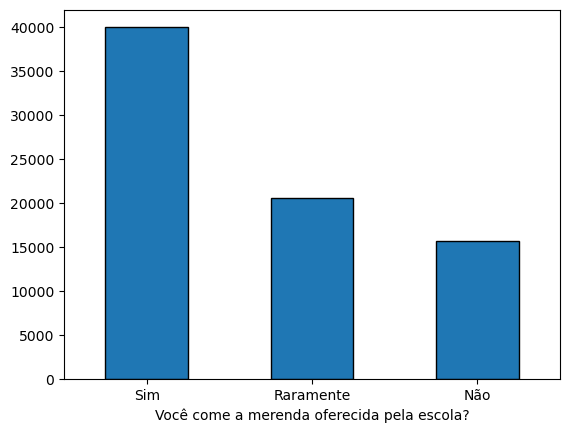

In [187]:
# drop(3) = ignorando os sem merenda na escola
print(df['B02020B'].rename("Você come a merenda oferecida pela escola?").value_counts().drop(3).sort_index().rename(index=mapa_freq_ref))
df['B02020B'].rename("Você come a merenda oferecida pela escola?").value_counts().drop(3).sort_index().rename(index=mapa_freq_ref).plot(kind='bar', edgecolor='black', rot=0)

In [188]:
df['B02041'].value_counts()

B02041
4.0    45706
5.0    40623
6.0    22875
1.0    19091
3.0    16015
2.0    13349
9.0      317
Name: count, dtype: int64

In [189]:
# sim
column_replace(df, 'B02041', 1, 0)
column_replace(df, 'B02041', 2, 0)
column_replace(df, 'B02041', 3, 0)

# raramente
column_replace(df, 'B02041', 4, 1)

# nao
column_replace(df, 'B02041', 5, 2)
column_replace(df, 'B02041', 6, 2)
column_replace(df, 'B02041', 9, 2)

Você compra alimentos na cantina?
Sim          48455
Raramente    45706
Não          63815
Name: count, dtype: int64


<AxesSubplot: xlabel='Você compra alimentos na cantina?'>

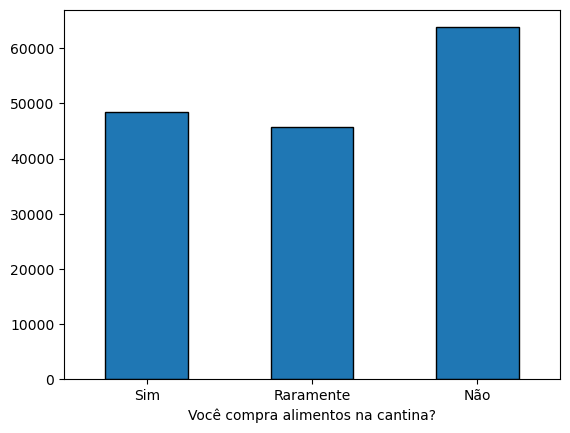

In [190]:
print(df['B02041'].rename("Você compra alimentos na cantina?").value_counts().sort_index().rename(index=mapa_freq_ref))
df['B02041'].rename("Você compra alimentos na cantina?").value_counts().sort_index().rename(index=mapa_freq_ref).plot(kind='bar', edgecolor='black', rot=0)

In [191]:
df['B02042'].value_counts()

B02042
4.0    54391
5.0    52242
6.0    27998
3.0    10634
2.0     6288
1.0     6161
9.0      262
Name: count, dtype: int64

In [192]:
# sim
column_replace(df, 'B02042', 1, 0)
column_replace(df, 'B02042', 2, 0)
column_replace(df, 'B02042', 3, 0)

# raramente
column_replace(df, 'B02042', 4, 1)

#nao
column_replace(df, 'B02042', 5, 2)
column_replace(df, 'B02042', 6, 2)
column_replace(df, 'B02042', 9, 2)

Você compra alimentos perto da escola?
Sim          23083
Raramente    54391
Não          80502
Name: count, dtype: int64


<AxesSubplot: xlabel='Você compra alimentos perto da escola?'>

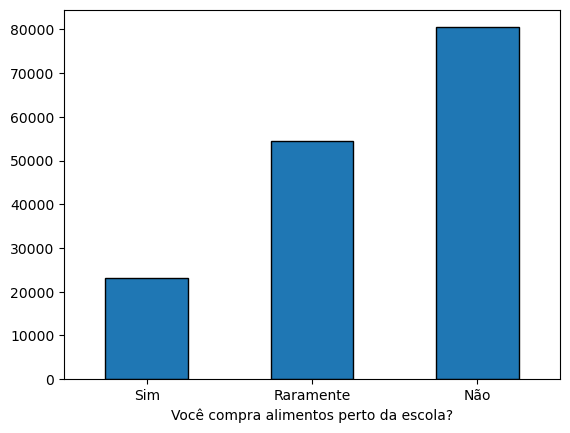

In [193]:
print(df['B02042'].rename("Você compra alimentos perto da escola?").value_counts().sort_index().rename(index=mapa_freq_ref))
df['B02042'].rename("Você compra alimentos perto da escola?").value_counts().sort_index().rename(index=mapa_freq_ref).plot(kind='bar', edgecolor='black', rot=0)

# Atividade Fisica



In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164569 entries, 0 to 165837
Columns: 292 entries, REGIAO to E01P27A
dtypes: float64(290), int64(2)
memory usage: 367.9 MB


In [195]:
df['B03001A1'].value_counts()

B03001A1
1.0    87642
6.0    43339
2.0     5721
7.0     5188
8.0     4788
3.0     3938
4.0     3607
5.0     3492
9.0      261
Name: count, dtype: int64

In [196]:
# nenhum dia
column_replace(df, 'B03001A1', 1, 0)
column_replace(df, 'B03001A1', 9, 0)

# pelo menos um dia
column_replace(df, 'B03001A1', 2, 1)
column_replace(df, 'B03001A1', 3, 1)
column_replace(df, 'B03001A1', 4, 1)
column_replace(df, 'B03001A1', 5, 1)
column_replace(df, 'B03001A1', 6, 1)

# dias da semana + sabado
column_replace(df, 'B03001A1', 7, 2)

# todos os dias
column_replace(df, 'B03001A1', 8, 3)

In [197]:
mapa_ape = {
    0: 'Nenhum dia',
    1: 'Pelo menos um dia',
    2: 'Dias de semana + sabado',
    3: 'Todos os dias'
}

Quantos dias você foi a pé/de bicicleta pra escola?
Nenhum dia                 87903
Pelo menos um dia          60097
Dias de semana + sabado     5188
Todos os dias               4788
Name: count, dtype: int64


<AxesSubplot: xlabel='Quantos dias você foi a pé/de bicicleta pra escola?'>

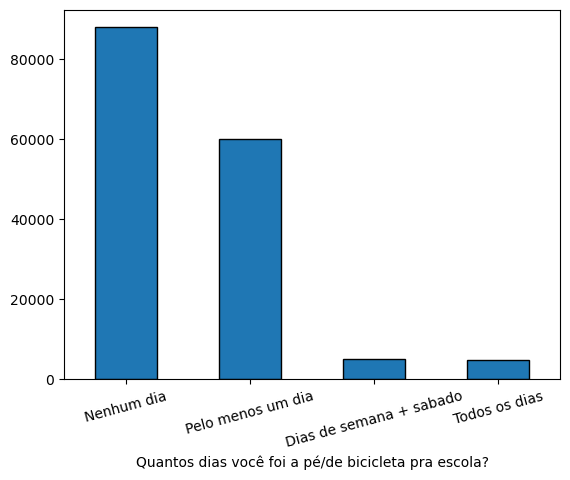

In [198]:
print(df['B03001A1'].rename("Quantos dias você foi a pé/de bicicleta pra escola?").value_counts().sort_index().rename(index=mapa_ape))
df['B03001A1'].rename("Quantos dias você foi a pé/de bicicleta pra escola?").value_counts().sort_index().rename(index=mapa_ape).plot(kind='bar', edgecolor='black', rot=15)

In [199]:
df['B03002A1'].value_counts()

B03002A1
-1.0    87903
 1.0    33377
 2.0    22414
 3.0     7467
 4.0     3406
 5.0     1330
 7.0     1275
 6.0      587
 9.0      217
Name: count, dtype: int64

In [200]:
# quem não vai a pé/de bicicleta
column_replace(df, 'B03002A1', -1, 8)
column_replace(df, 'B03002A1', 9, 8)

normaliza_coluna(df, 'B03002A1')

In [201]:
mapa_ape_t = {
    0: '< 10 minutos',
    1: '< 20 minutos',
    2: '< 30 minutos',
    3: '< 40 minutos',
    4: '< 50 minutos',
    5: '< 60 minutos',
    6: '> 1 hora'
}

Quanto tempo você gasta para ir a pé/de bicicleta pra escola?
< 10 minutos    33377
< 20 minutos    22414
< 30 minutos     7467
< 40 minutos     3406
< 50 minutos     1330
< 60 minutos      587
> 1 hora         1275
Name: count, dtype: int64


<AxesSubplot: xlabel='Quanto tempo você gasta para ir a pé/de bicicleta pra escola?'>

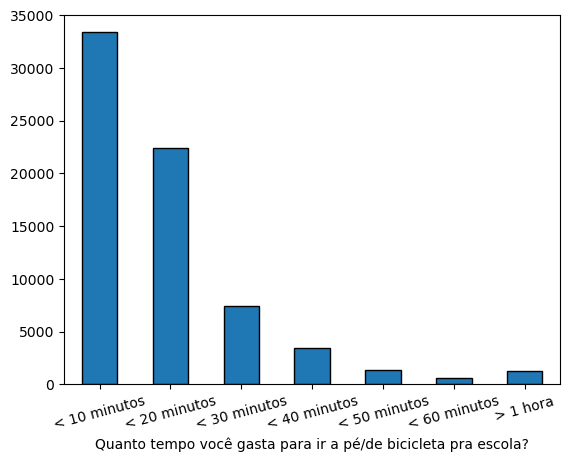

In [202]:
# drop(7) - quem não vai para escola a pé/de biclicleta
print(df['B03002A1'].rename("Quanto tempo você gasta para ir a pé/de bicicleta pra escola?").value_counts().drop(7).sort_index().rename(index=mapa_ape_t))
df['B03002A1'].rename("Quanto tempo você gasta para ir a pé/de bicicleta pra escola?").value_counts().drop(7).sort_index().rename(index=mapa_ape_t).plot(kind='bar', edgecolor='black', rot=15)

In [203]:
df['B03001A2'].value_counts()

B03001A2
1.0    82238
6.0    47698
2.0     6641
7.0     5212
3.0     4685
4.0     4044
5.0     3695
8.0     3422
9.0      341
Name: count, dtype: int64

In [204]:
# nenhum dia
column_replace(df, 'B03001A2', 1, 0)
column_replace(df, 'B03001A2', 9, 0)

# pelo menos um dia
column_replace(df, 'B03001A2', 2, 1)
column_replace(df, 'B03001A2', 3, 1)
column_replace(df, 'B03001A2', 4, 1)
column_replace(df, 'B03001A2', 5, 1)
column_replace(df, 'B03001A2', 6, 1)

# dias da semana + sabado
column_replace(df, 'B03001A2', 7, 2)

# todos os dias
column_replace(df, 'B03001A2', 8, 3)

Quantos dias você voltou a pé/de bicicleta da escola?
Nenhum dia                 82579
Pelo menos um dia          66763
Dias de semana + sabado     5212
Todos os dias               3422
Name: count, dtype: int64


<AxesSubplot: xlabel='Quantos dias você voltou a pé/de bicicleta da escola?'>

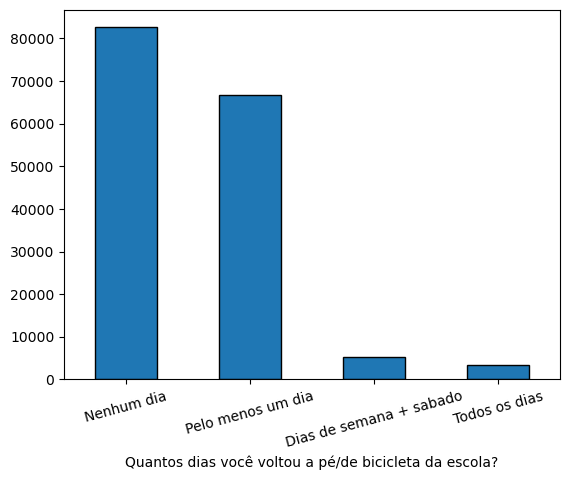

In [205]:
print(df['B03001A2'].rename("Quantos dias você voltou a pé/de bicicleta da escola?").value_counts().sort_index().rename(index=mapa_ape))
df['B03001A2'].rename("Quantos dias você voltou a pé/de bicicleta da escola?").value_counts().sort_index().rename(index=mapa_ape).plot(kind='bar', edgecolor='black', rot=15)

In [206]:
df['B03002A2'].value_counts()

B03002A2
-1.0    82579
 1.0    31999
 2.0    24879
 3.0     9654
 4.0     4462
 5.0     1879
 7.0     1495
 6.0      847
 9.0      182
Name: count, dtype: int64

In [207]:
# quem não vai a pé/de bicicleta
column_replace(df, 'B03002A2', -1, 8)
column_replace(df, 'B03002A2', 9, 8)

normaliza_coluna(df, 'B03002A2')

Quanto tempo você gasta para voltar a pé/de bicicleta da escola?
< 10 minutos    31999
< 20 minutos    24879
< 30 minutos     9654
< 40 minutos     4462
< 50 minutos     1879
< 60 minutos      847
> 1 hora         1495
Name: count, dtype: int64


<AxesSubplot: xlabel='Quanto tempo você gasta para voltar a pé/de bicicleta da escola?'>

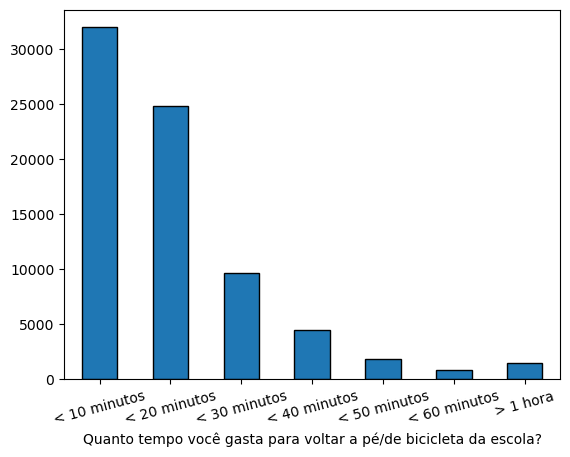

In [208]:
# drop(7) - quem não volta da escola a pé/de biclicletta
print(df['B03002A2'].rename("Quanto tempo você gasta para voltar a pé/de bicicleta da escola?").value_counts().drop(7).sort_index().rename(index=mapa_ape_t))
df['B03002A2'].rename("Quanto tempo você gasta para voltar a pé/de bicicleta da escola?").value_counts().drop(7).sort_index().rename(index=mapa_ape_t).plot(kind='bar', edgecolor='black', rot=15)

In [209]:
df['B03003A'].value_counts()

B03003A
2.0    68077
3.0    41313
1.0    35404
4.0     6481
6.0     3254
5.0     2419
9.0      375
8.0      354
7.0      299
Name: count, dtype: int64

In [210]:
# nenhum dia
column_replace(df, 'B03003A', 9, 0)
column_replace(df, 'B03003A', 1, 0)

# 1 dia na semana
column_replace(df, 'B03003A', 2, 1)

# 2 ou 3 dias
column_replace(df, 'B03003A', 3, 2)
column_replace(df, 'B03003A', 4, 2)

# mais de 3 dias
column_replace(df, 'B03003A', 5, 3)
column_replace(df, 'B03003A', 6, 3)
column_replace(df, 'B03003A', 7, 3)
column_replace(df, 'B03003A', 8, 3)

In [211]:
mapa_ed_fisica = {
    0: 'Nenhum dia',
    1: '1 dia',
    2: '2 ou 3 dias',
    3: '> 3 dias'
}

Quantos dias da semana você tem educação física na escola?
Nenhum dia     35779
1 dia          68077
2 ou 3 dias    47794
> 3 dias        6326
Name: count, dtype: int64


<AxesSubplot: xlabel='Quantos dias da semana você tem educação física na escola?'>

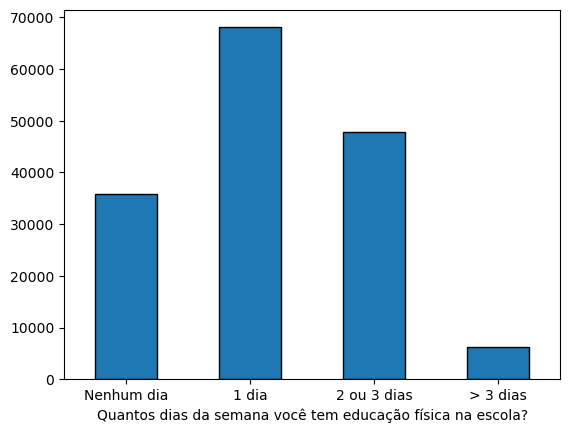

In [212]:
print(df['B03003A'].rename("Quantos dias da semana você tem educação física na escola?").value_counts().sort_index().rename(index=mapa_ed_fisica))
df['B03003A'].rename("Quantos dias da semana você tem educação física na escola?").value_counts().sort_index().rename(index=mapa_ed_fisica).plot(kind='bar', edgecolor='black', rot=0)

In [213]:
df['B03005B'].value_counts()

B03005B
-1.0     35779
 1.0     28062
 6.0     21672
 7.0     14032
 5.0     13913
 9.0     11172
 4.0     10201
 3.0      8928
 2.0      8806
 8.0      5035
 99.0      376
Name: count, dtype: int64

In [214]:
column_replace(df, 'B03005B', -1, 10)
column_replace(df, 'B03005B', 99, 10)

normaliza_coluna(df, 'B03005B')

In [215]:
mapa_ed_fisica_t = {
    0: 'Não fez na aula',
    1: '< 10 minutos',
    2: '< 20 minutos',
    3: '< 30 minutos',
    4: '< 40 minutos',
    5: '< 50 minutos',
    6: '< 1 hora',
    7: '< 1 hora e 20 minutos',
    8: '> 1 hora e 20 minutos'
}

Quanto tempo de atividade física/esporte durante a aula de educação física?
Não fez na aula          28062
< 10 minutos              8806
< 20 minutos              8928
< 30 minutos             10201
< 40 minutos             13913
< 50 minutos             21672
< 1 hora                 14032
< 1 hora e 20 minutos     5035
> 1 hora e 20 minutos    11172
Name: count, dtype: int64


<AxesSubplot: xlabel='Quanto tempo de atividade física/esporte durante a aula de educação física?'>

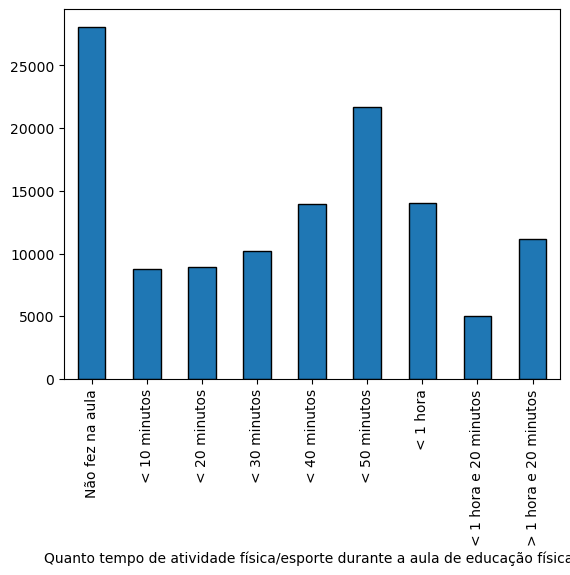

In [216]:
# drop(9) = não tiveram aula de educação física
print(df['B03005B'].rename("Quanto tempo de atividade física/esporte durante a aula de educação física?").value_counts().drop(9).sort_index().rename(index=mapa_ed_fisica_t))
df['B03005B'].rename("Quanto tempo de atividade física/esporte durante a aula de educação física?").value_counts().drop(9).sort_index().rename(index=mapa_ed_fisica_t).plot(kind='bar', edgecolor='black', rot=90)

In [217]:
df['B03006B'].value_counts()

B03006B
1.0    53056
3.0    20990
4.0    18267
2.0    18149
6.0    15120
8.0    13992
5.0    11415
7.0     6676
9.0      311
Name: count, dtype: int64

In [218]:
column_replace(df, 'B03006B',9, 1)

normaliza_coluna(df, 'B03006B')

In [219]:
mapa_dias = {
    0: 'Nenhum dia',
    1: '1 dia',
    2: '2 dias',
    3: '3 dias',
    4: '4 dias',
    5: '5 dias',
    6: '6 dias',
    7: '7 dias'
}

Quantos dias você fez atividade física fora da escola?
Nenhum dia    53367
1 dia         18149
2 dias        20990
3 dias        18267
4 dias        11415
5 dias        15120
6 dias         6676
7 dias        13992
Name: count, dtype: int64


<AxesSubplot: xlabel='Quantos dias você fez atividade física fora da escola?'>

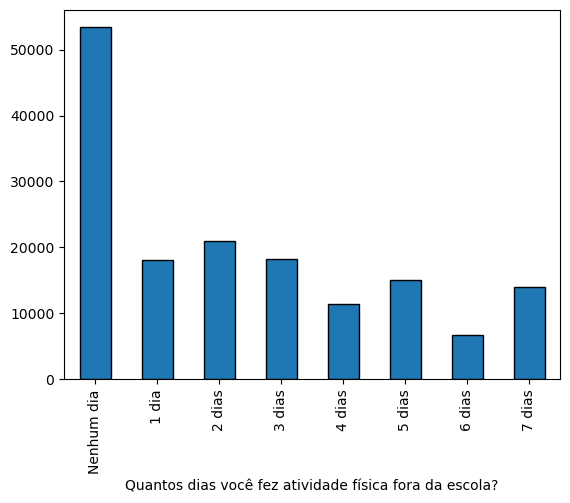

In [220]:
print(df['B03006B'].rename("Quantos dias você fez atividade física fora da escola?").value_counts().sort_index().rename(index=mapa_dias))
df['B03006B'].rename("Quantos dias você fez atividade física fora da escola?").value_counts().sort_index().rename(index=mapa_dias).plot(kind='bar', edgecolor='black', rot=90)

In [221]:
df['B03007A'].value_counts()

B03007A
-1.0    53367
 8.0    24914
 6.0    13835
 2.0    12751
 7.0    11996
 3.0    11246
 4.0    11156
 1.0     9972
 5.0     8507
 9.0      232
Name: count, dtype: int64

In [222]:
column_replace(df, 'B03007A', -1, 9)

normaliza_coluna(df, 'B03007A')

In [223]:
mapa_at_t = {
    0: '< 10 minutos',
    1: '< 20 minutos',
    2: '< 30 minutos',
    3: '< 40 minutos',
    4: '< 50 minutos',
    5: '< 1 hora',
    6: '< 1 hora e 20 minutos',
    7: '> 1 hora e 20 minutos'
}

Quanto tempo você passou fazendo atividade física fora da escola?
< 10 minutos              9972
< 20 minutos             12751
< 30 minutos             11246
< 40 minutos             11156
< 50 minutos              8507
< 1 hora                 13835
< 1 hora e 20 minutos    11996
> 1 hora e 20 minutos    24914
Name: count, dtype: int64


<AxesSubplot: xlabel='Quanto tempo você passou fazendo atividade física fora da escola?'>

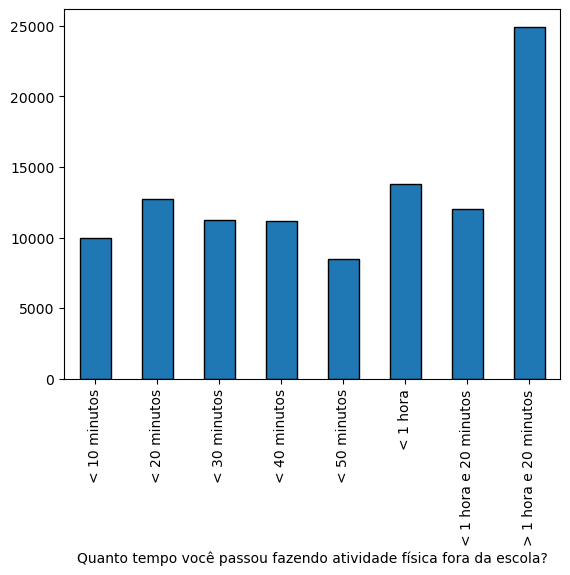

In [224]:
# drop(8) = quem não faz atividade física fora de casa
print(df['B03007A'].rename("Quanto tempo você passou fazendo atividade física fora da escola?").value_counts().drop(8).sort_index().rename(index=mapa_at_t))
df['B03007A'].rename("Quanto tempo você passou fazendo atividade física fora da escola?").value_counts().drop(8).sort_index().rename(index=mapa_at_t).plot(kind='bar', edgecolor='black', rot=90)

In [225]:
df['B03009B'].value_counts()

B03009B
2.0     39527
1.0     38649
3.0     26108
4.0     17662
5.0     11346
6.0      7190
10.0     5963
7.0      4890
9.0      3601
8.0      2742
99.0      298
Name: count, dtype: int64

In [226]:
column_replace(df, 'B03009B', 99, 1)

normaliza_coluna(df, 'B03009B')

In [227]:
mapa_tv_t = {
    0: 'Não assiste TV',
    1: '< 1 hora',
    2: '< 2 horas',
    3: '< 3 horas',
    4: '< 4 horas',
    5: '< 5 horas',
    6: '< 6 horas',
    7: '< 7 horas',
    8: '< 8 horas',
    9: '> 8 horas'
}

<AxesSubplot: xlabel='Quanto tempo você passa assistiindo TV?'>

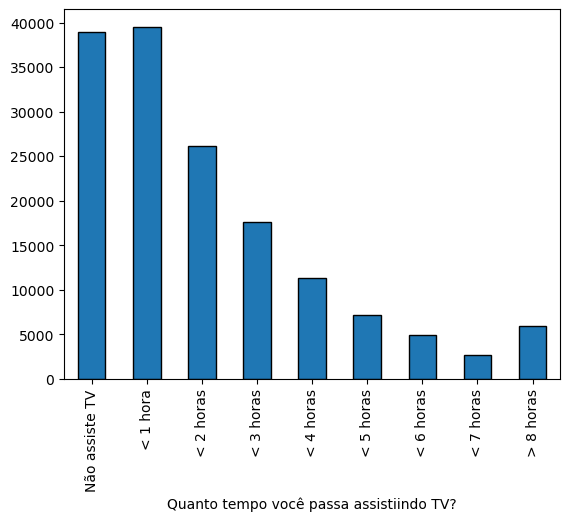

In [228]:
df['B03009B'].rename("Quanto tempo você passa assistiindo TV?").value_counts().drop(8).sort_index().rename(index=mapa_tv_t).plot(kind='bar', edgecolor='black', rot=90)

In [229]:
df['B03010B'].value_counts()

B03010B
1.0     26527
3.0     22405
2.0     20935
4.0     20890
5.0     17338
9.0     16902
6.0     13806
7.0     11123
8.0      5904
99.0     2146
Name: count, dtype: int64

In [230]:
column_replace(df, 'B03010B', 99, 1)

normaliza_coluna(df, 'B03010B')

In [231]:
mapa_sentado = {
    0: '< 1 hora',
    1: '< 2 horas',
    2: '< 3 horas',
    3: '< 4 horas',
    4: '< 5 horas',
    5: '< 6 horas',
    6: '< 7 horas',
    7: '< 8 horas',
    8: '> 8 horas'
}

Quanto tempo você passa sentado?
< 1 hora     28673
< 2 horas    20935
< 3 horas    22405
< 4 horas    20890
< 5 horas    17338
< 6 horas    13806
< 7 horas    11123
< 8 horas     5904
> 8 horas    16902
Name: count, dtype: int64


<AxesSubplot: xlabel='Quanto tempo você passa sentado?'>

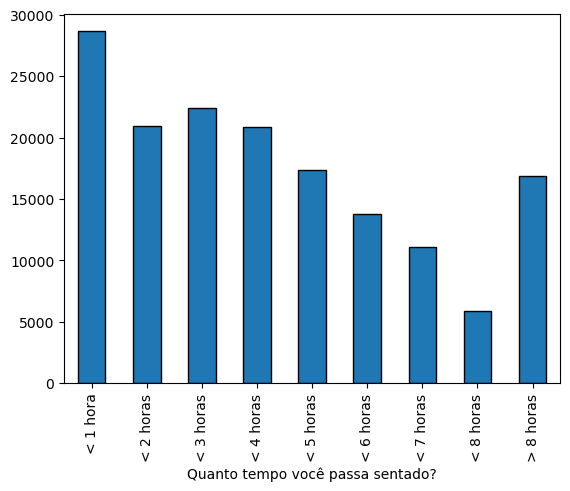

In [232]:
print(df['B03010B'].rename("Quanto tempo você passa sentado?").value_counts().sort_index().rename(index=mapa_sentado))
df['B03010B'].rename("Quanto tempo você passa sentado?").value_counts().sort_index().rename(index=mapa_sentado).plot(kind='bar', edgecolor='black', rot=90)

# Uso de Cigarro

In [233]:
df['B04001'].value_counts()

## O que fazer com esses dados ??
## Onde encaixa os sem respostas

B04001
 2.0    103858
 1.0     28441
-1.0     25546
 9.0       131
Name: count, dtype: int64

In [234]:
column_replace(df, 'B04001', -1, 0)
column_replace(df, 'B04001', 9, 2)


In [235]:
mapa_uso_cig = {
    0: 'Sem resposta',
    1: 'Sim',
    2: 'Não'
}

Você já fumou cigarro?
Sem resposta     25546
Sim              28441
Não             103989
Name: count, dtype: int64


<AxesSubplot: xlabel='Você já fumou cigarro?'>

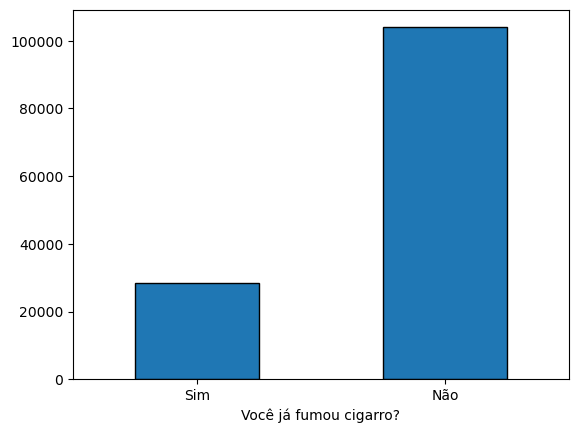

In [236]:
print(df['B04001'].rename("Você já fumou cigarro?").value_counts().sort_index().rename(index=mapa_uso_cig))
df['B04001'].rename("Você já fumou cigarro?").value_counts().drop(0).sort_index().rename(index=mapa_uso_cig).plot(kind='bar', edgecolor='black', rot=0)


In [237]:
df['B04002A'].value_counts()

B04002A
-1.0     129535
 14.0      5475
 15.0      5006
 13.0      4485
 16.0      3374
 12.0      3137
 9.0       2007
 11.0      1559
 17.0      1439
 10.0      1300
 18.0       529
 99.0       130
Name: count, dtype: int64

In [238]:
mapa_idades_cig = {
    0: 'Sem resposta',
    1: '< 10 anos',
    2: '10 anos',
    3: '11 anos',
    4: '12 anos',
    5: '13 anos',
    6: '14 anos',
    7: '15 anos',
    8: '16 anos',
    9: '17 anos',
    10: '> 17 anos'
}

In [239]:
column_replace(df, 'B04002A', -1, 0) # muitos pulos
column_replace(df, 'B04002A', 99, 0)
column_replace(df, 'B04002A', 9, 1)
column_replace(df, 'B04002A', 10, 2)
column_replace(df, 'B04002A', 11, 3)
column_replace(df, 'B04002A', 12, 4)
column_replace(df, 'B04002A', 13, 5)
column_replace(df, 'B04002A', 14, 6)
column_replace(df, 'B04002A', 15, 7)
column_replace(df, 'B04002A', 16, 8)
column_replace(df, 'B04002A', 17, 9)
column_replace(df, 'B04002A', 18, 10)

Que idade tinha quando fumou?
Sem resposta    129665
< 10 anos         2007
10 anos           1300
11 anos           1559
12 anos           3137
13 anos           4485
14 anos           5475
15 anos           5006
16 anos           3374
17 anos           1439
> 17 anos          529
Name: count, dtype: int64


<AxesSubplot: xlabel='Que idade tinha quando fumou?'>

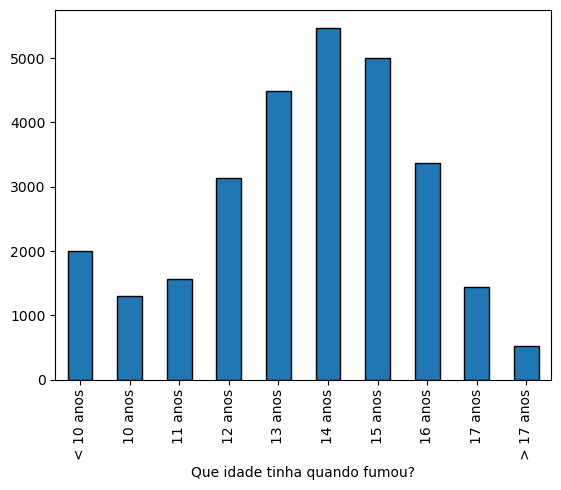

In [240]:
print(df['B04002A'].rename("Que idade tinha quando fumou?").value_counts().sort_index().rename(index=mapa_idades_cig))
df['B04002A'].rename("Que idade tinha quando fumou?").value_counts().drop(0).sort_index().rename(index=mapa_idades_cig).plot(kind='bar', edgecolor='black', rot=90)

In [241]:
df['B04003'].value_counts()

B04003
-1.0    129535
 1.0     20200
 2.0      4034
 3.0      1277
 7.0       967
 5.0       735
 4.0       728
 6.0       421
 9.0        79
Name: count, dtype: int64

In [242]:
column_replace(df, 'B04003', 9, 0)
column_replace(df, 'B04003', -1, 0)

In [243]:
mapa_ult30 = {
    0: 'Sem resposta',
    1: 'Nenhum',
    2: '< 3 dias',
    3: '< 6 dias',
    4: '< 10 dias',
    5: '< 20 dias',
    6: '< 30 dias',
    7: 'Todos os dias'
}

Quantos dias fumou no último mes?
Sem resposta     129614
Nenhum            20200
< 3 dias           4034
< 6 dias           1277
< 10 dias           728
< 20 dias           735
< 30 dias           421
Todos os dias       967
Name: count, dtype: int64


<AxesSubplot: xlabel='Quantos dias fumou no último mes?'>

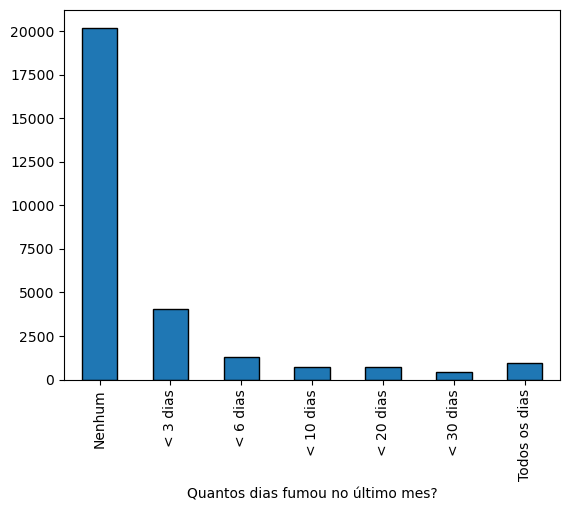

In [244]:
print(df['B04003'].rename("Quantos dias fumou no último mes?").value_counts().sort_index().rename(index=mapa_ult30))
df['B04003'].rename("Quantos dias fumou no último mes?").value_counts().drop(0).sort_index().rename(index=mapa_ult30).plot(kind='bar', edgecolor='black', rot=90)

In [245]:
df['B04009A'].value_counts()

B04009A
-1.0    149814
 1.0      3151
 4.0      1697
 7.0      1158
 3.0       675
 6.0       557
 2.0       457
 5.0       400
 9.0        67
Name: count, dtype: int64

In [246]:
mapa_adq_cig = {
    0: 'Sem resposta',
    1: 'Comprou',
    2: 'Ganhou',
    3: 'Pegou escondido',
    4: 'Outro'
}

In [247]:
column_replace(df, 'B04009A', -1, 0)
column_replace(df, 'B04009A', 9, 0)

column_replace(df, 'B04009A', 2, 1)
column_replace(df, 'B04009A', 3, 1)

column_replace(df, 'B04009A', 4, 2)
column_replace(df, 'B04009A', 6, 2)

column_replace(df, 'B04009A', 5, 3)

column_replace(df, 'B04009A', 7, 4)

Como conseguiu cigarro?
Sem resposta       149881
Comprou              4283
Ganhou               2254
Pegou escondido       400
Outro                1158
Name: count, dtype: int64


<AxesSubplot: xlabel='Como conseguiu cigarro?'>

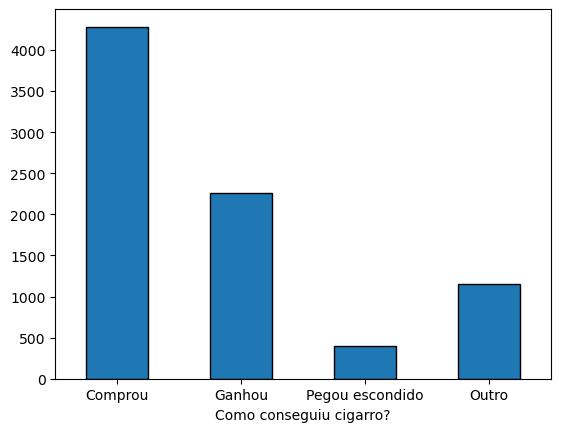

In [248]:
print(df['B04009A'].rename("Como conseguiu cigarro?").value_counts().sort_index().rename(index=mapa_adq_cig))
df['B04009A'].rename("Como conseguiu cigarro?").value_counts().drop(0).sort_index().rename(index=mapa_adq_cig).plot(kind='bar', edgecolor='black', rot=0)


In [249]:
df['B04010'].value_counts()

B04010
 1.0    116442
-1.0     25546
 3.0     11212
 2.0      3632
 9.0      1144
Name: count, dtype: int64

In [250]:
column_replace(df, 'B04010', -1, 0)
column_replace(df, 'B04010', 9, 0)

In [251]:
mapa_sn_cig = {
    0: 'Sem resposta',
    1: 'Não tentou comprar',
    2: 'Sim',
    3: 'Não'
}

Alguém recusou vender cigarro?
Sem resposta           26690
Não tentou comprar    116442
Sim                     3632
Não                    11212
Name: count, dtype: int64


<AxesSubplot: xlabel='Alguém recusou vender cigarro?'>

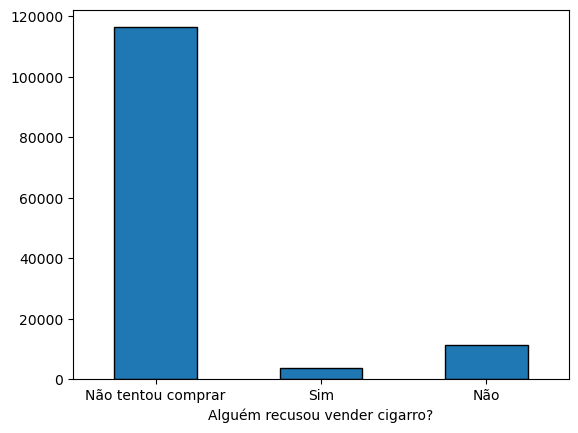

In [252]:
print(df['B04010'].rename("Alguém recusou vender cigarro?").value_counts().sort_index().rename(index=mapa_sn_cig))
df['B04010'].rename("Alguém recusou vender cigarro?").value_counts().drop(0).sort_index().rename(index=mapa_sn_cig).plot(kind='bar', edgecolor='black', rot=0)


In [253]:
df['B04012'].value_counts()

B04012
-1.0    141988
 2.0     10774
 1.0      4878
 9.0       336
Name: count, dtype: int64

In [254]:
column_replace(df, 'B04012', -1, 3)
column_replace(df, 'B04012', 9, 3)

normaliza_coluna(df, 'B04012')

Comprou cigarro avulso?
Sim               4878
Não              10774
Sem resposta    142324
Name: count, dtype: int64


<AxesSubplot: xlabel='Comprou cigarro avulso?'>

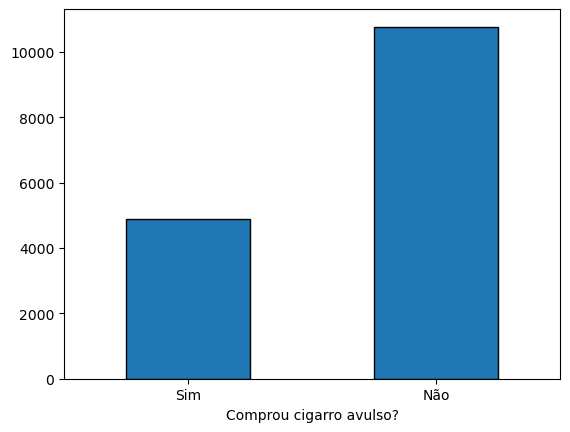

In [255]:
print(df['B04012'].rename("Comprou cigarro avulso?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04012'].rename("Comprou cigarro avulso?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)


In [256]:
df['B04013'].value_counts()

B04013
 2.0    102799
 1.0     29439
-1.0     25546
 9.0       192
Name: count, dtype: int64

In [257]:
column_replace(df, 'B04013', -1, 3)
column_replace(df, 'B04013', 9, 3)

normaliza_coluna(df, 'B04013')

Ja fumou narguilé?
Sim              29439
Não             102799
Sem resposta     25738
Name: count, dtype: int64


<AxesSubplot: xlabel='Ja fumou narguilé?'>

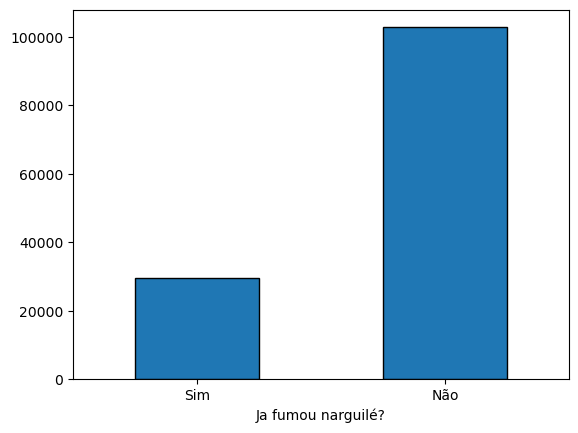

In [258]:
print(df['B04013'].rename("Ja fumou narguilé?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04013'].rename("Ja fumou narguilé?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [259]:
df['B04014'].value_counts()

B04014
 2.0    108438
-1.0     25546
 1.0     23793
 9.0       199
Name: count, dtype: int64

In [260]:
column_replace(df, 'B04014', -1, 3)
column_replace(df, 'B04014', 9, 3)

normaliza_coluna(df, 'B04014')

Ja fumou cigarro eletrônico?
Sim              23793
Não             108438
Sem resposta     25745
Name: count, dtype: int64


<AxesSubplot: xlabel='Ja fumou cigarro eletrônico?'>

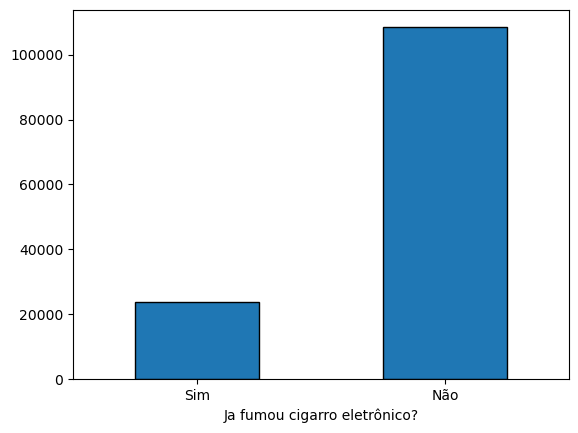

In [261]:
print(df['B04014'].rename("Ja fumou cigarro eletrônico?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04014'].rename("Ja fumou cigarro eletrônico?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [262]:
df['B04015'].value_counts()

B04015
 2.0    120261
-1.0     25546
 1.0     11925
 9.0       244
Name: count, dtype: int64

In [263]:
column_replace(df, 'B04015', -1, 3)
column_replace(df, 'B04015', 9, 3)

normaliza_coluna(df, 'B04015')

Ja usou outros produtos do tabaco?
Sim              11925
Não             120261
Sem resposta     25790
Name: count, dtype: int64


<AxesSubplot: xlabel='Ja usou outros produtos do tabaco?'>

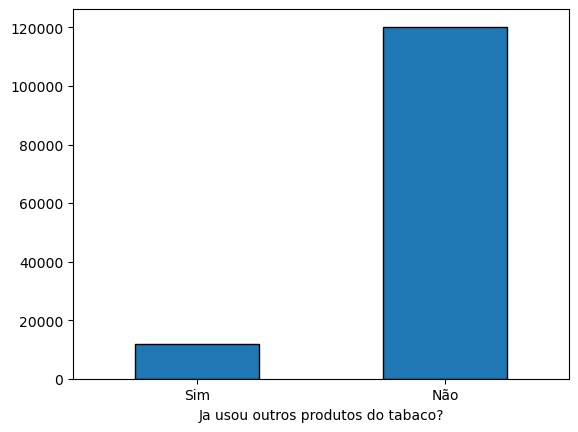

In [264]:
print(df['B04015'].rename("Ja usou outros produtos do tabaco?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04015'].rename("Ja usou outros produtos do tabaco?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [265]:
df['B04011A01'].value_counts()

B04011A01
-1.0    118550
 1.0     24793
 0.0     14438
 9.0       195
Name: count, dtype: int64

In [266]:
column_replace(df, 'B04011A01', -1, 2)
column_replace(df, 'B04011A01', 9, 2)

Nos últimos 30 dias usou produto de tabaco?
Sim              14438
Não              24793
Sem resposta    118745
Name: count, dtype: int64


<AxesSubplot: xlabel='Nos últimos 30 dias usou produto de tabaco?'>

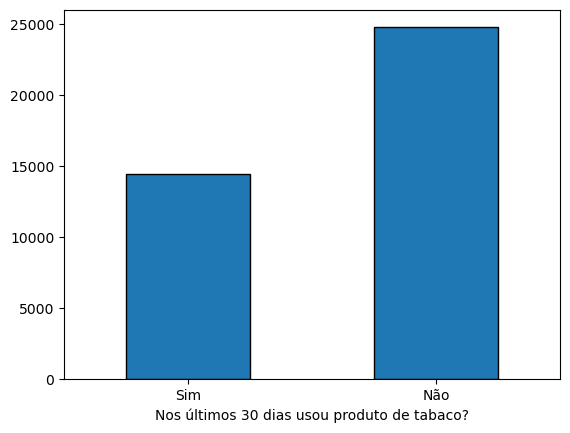

In [267]:
print(df['B04011A01'].rename("Nos últimos 30 dias usou produto de tabaco?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04011A01'].rename("Nos últimos 30 dias usou produto de tabaco?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)


In [268]:
df['B04011A02'].value_counts()

B04011A02
-1.0    118550
 0.0     31186
 1.0      8045
 9.0       195
Name: count, dtype: int64

In [269]:
column_replace(df, 'B04011A02', 0, 2)

column_replace(df, 'B04011A02', -1, 3)
column_replace(df, 'B04011A02', 9, 3)

normaliza_coluna(df, 'B04011A02')

Nos últimos 30 dias usou narguilé?
Sim               8045
Não              31186
Sem resposta    118745
Name: count, dtype: int64


<AxesSubplot: xlabel='Nos últimos 30 dias usou narguilé?'>

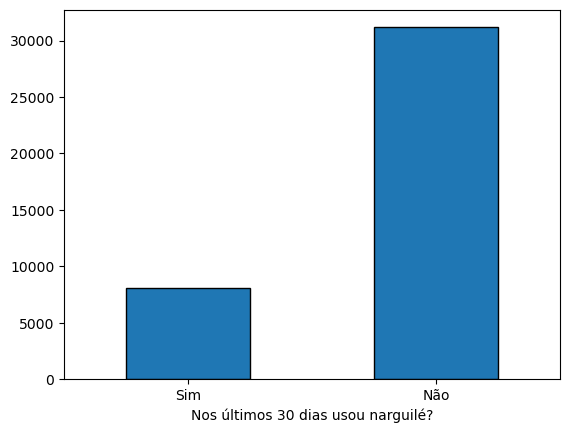

In [270]:
print(df['B04011A02'].rename("Nos últimos 30 dias usou narguilé?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04011A02'].rename("Nos últimos 30 dias usou narguilé?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [271]:
df['B04011A03'].value_counts()

B04011A03
-1.0    118550
 0.0     34732
 1.0      4499
 9.0       195
Name: count, dtype: int64

In [272]:
column_replace(df, 'B04011A03', 0, 2)

column_replace(df, 'B04011A03', -1, 3)
column_replace(df, 'B04011A03', 9, 3)

normaliza_coluna(df, 'B04011A03')

Nos últimos 30 dias usou cigarro eletronico?
Sim               4499
Não              34732
Sem resposta    118745
Name: count, dtype: int64


<AxesSubplot: xlabel='Nos últimos 30 dias usou cigarro eletronico?'>

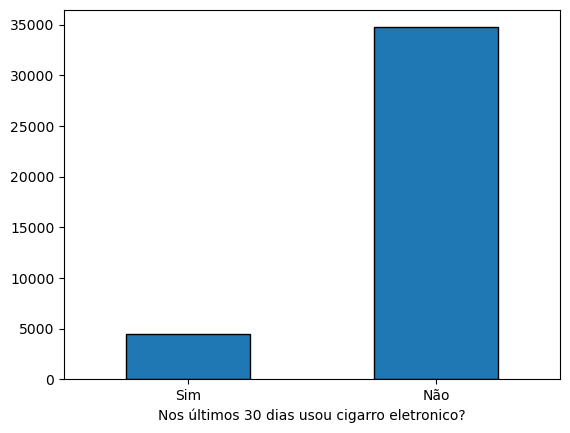

In [273]:
print(df['B04011A03'].rename("Nos últimos 30 dias usou cigarro eletronico?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04011A03'].rename("Nos últimos 30 dias usou cigarro eletronico?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [274]:
df['B04011A04'].value_counts()

B04011A04
-1.0    118550
 0.0     38285
 1.0       946
 9.0       195
Name: count, dtype: int64

In [275]:
column_replace(df, 'B04011A04', 0, 2)

column_replace(df, 'B04011A04', -1, 3)
column_replace(df, 'B04011A04', 9, 3)

normaliza_coluna(df, 'B04011A04')

Nos últimos 30 dias usou cigarro de cravo?
Sim                946
Não              38285
Sem resposta    118745
Name: count, dtype: int64


<AxesSubplot: xlabel='Nos últimos 30 dias usou cigarro de cravo?'>

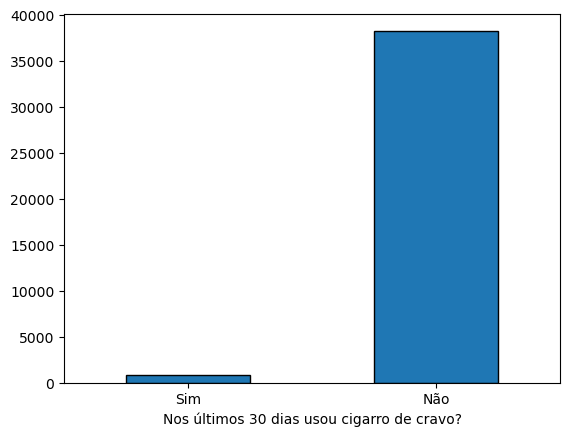

In [276]:
print(df['B04011A04'].rename("Nos últimos 30 dias usou cigarro de cravo?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04011A04'].rename("Nos últimos 30 dias usou cigarro de cravo?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [277]:
df['B04011A05'].value_counts()

B04011A05
-1.0    118550
 0.0     35794
 1.0      3437
 9.0       195
Name: count, dtype: int64

In [278]:
column_replace(df, 'B04011A05', 0, 2)

column_replace(df, 'B04011A05', -1, 3)
column_replace(df, 'B04011A05', 9, 3)

normaliza_coluna(df, 'B04011A05')

Nos últimos 30 dias usou cigarro de palha?
Sim               3437
Não              35794
Sem resposta    118745
Name: count, dtype: int64


<AxesSubplot: xlabel='Nos últimos 30 dias usou cigarro de palha?'>

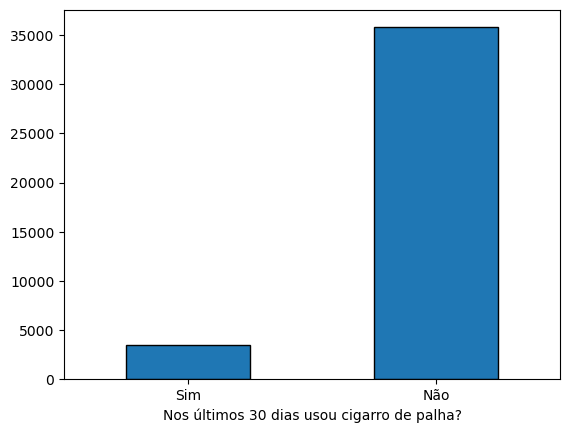

In [279]:
print(df['B04011A05'].rename("Nos últimos 30 dias usou cigarro de palha?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04011A05'].rename("Nos últimos 30 dias usou cigarro de palha?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [280]:
df['B04011A06'].value_counts()

B04011A06
-1.0    118550
 0.0     36537
 1.0      2694
 9.0       195
Name: count, dtype: int64

In [281]:
column_replace(df, 'B04011A06', 0, 2)

column_replace(df, 'B04011A06', -1, 3)
column_replace(df, 'B04011A06', 9, 3)

normaliza_coluna(df, 'B04011A06')

Nos últimos 30 dias usou outro tipo de tabaco?
Sim               2694
Não              36537
Sem resposta    118745
Name: count, dtype: int64


<AxesSubplot: xlabel='Nos últimos 30 dias usou outro tipo de tabaco?'>

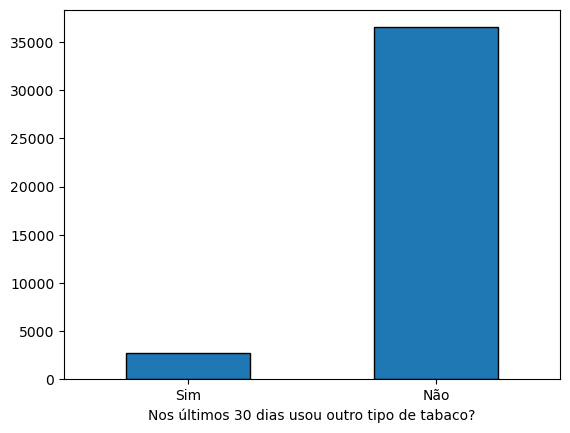

In [282]:
print(df['B04011A06'].rename("Nos últimos 30 dias usou outro tipo de tabaco?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04011A06'].rename("Nos últimos 30 dias usou outro tipo de tabaco?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

In [283]:
df['B04006B'].value_counts()

B04006B
 1.0    104146
-1.0     25546
 2.0     14078
 3.0      7760
 4.0      4017
 5.0      2262
 9.0       167
Name: count, dtype: int64

In [284]:
column_replace(df, 'B04006B', -1, 5)
column_replace(df, 'B04006B', 9, 5)

normaliza_coluna(df, 'B04006B')

In [285]:
mapa_pais_cig = {
    0: 'Nenhum',
    1: 'Apenas o pai',
    2: 'Apenas a mãe',
    3: 'Ambos',
    4: 'Sem resposta'
}

Seus responsáveis fumam?
Nenhum          104146
Apenas o pai     14078
Apenas a mãe      7760
Ambos             4017
Sem resposta     27975
Name: count, dtype: int64


<AxesSubplot: xlabel='Seus responsáveis fumam?'>

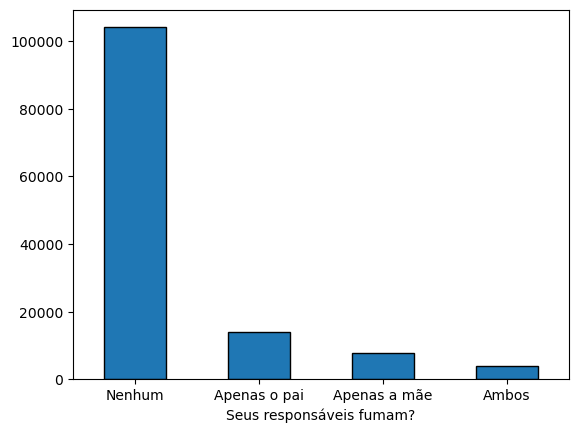

In [286]:
print(df['B04006B'].rename("Seus responsáveis fumam?").value_counts().sort_index().rename(index=mapa_pais_cig))
df['B04006B'].rename("Seus responsáveis fumam?").value_counts().drop(4).sort_index().rename(index=mapa_pais_cig).plot(kind='bar', edgecolor='black', rot=0)

In [287]:
df['B04005A'].value_counts()


B04005A
 1.0    102151
-1.0     25546
 5.0     12736
 2.0     10895
 3.0      3968
 4.0      2281
 9.0       399
Name: count, dtype: int64

In [288]:
column_replace(df, 'B04005A', -1, 0)
column_replace(df, 'B04005A', 9, 0)

In [289]:
mapa_ult7 = {
    0: 'Sem resposta',
    1: 'Nenhum',
    2: '< 3 dias',
    3: '< 5 dias',
    4: '< 7 dias',
    5: 'Todos os dias'
}

Na última semana quantos dias fumaram em sua casa?
Sem resposta      25945
Nenhum           102151
< 3 dias          10895
< 5 dias           3968
< 7 dias           2281
Todos os dias     12736
Name: count, dtype: int64


<AxesSubplot: xlabel='Na última semana quantos dias fumaram em sua casa?'>

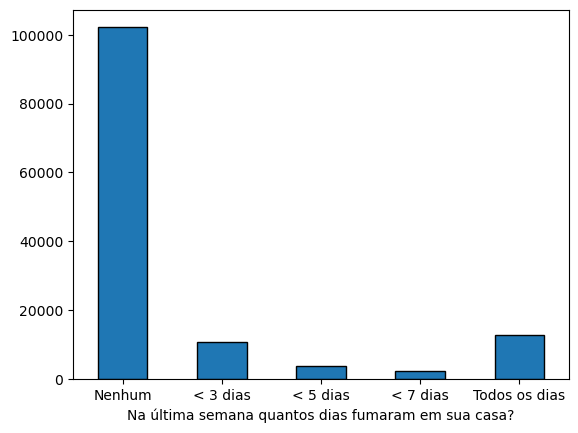

In [290]:
print(df['B04005A'].rename("Na última semana quantos dias fumaram em sua casa?").value_counts().sort_index().rename(index=mapa_ult7))
df['B04005A'].rename("Na última semana quantos dias fumaram em sua casa?").value_counts().drop(0).sort_index().rename(index=mapa_ult7).plot(kind='bar', edgecolor='black', rot=0)

In [291]:
df['B04016'].value_counts()

B04016
 2.0    97980
 1.0    34249
-1.0    25546
 9.0      201
Name: count, dtype: int64

In [292]:
column_replace(df, 'B04016', -1, 3)
column_replace(df, 'B04016', 9, 3)

normaliza_coluna(df, 'B04016')

Algum de seus amigos fumou na sua presença?
Sim             34249
Não             97980
Sem resposta    25747
Name: count, dtype: int64


<AxesSubplot: xlabel='Algum de seus amigos fumou na sua presença?'>

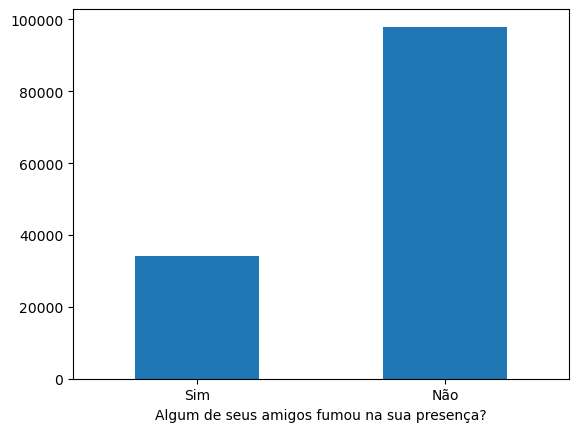

In [ ]:
print(df['B04016'].rename("Algum de seus amigos fumou na sua presença?").value_counts().sort_index().rename(index=mapa_sim_nao))
df['B04016'].rename("Algum de seus amigos fumou na sua presença?").value_counts().drop(2).sort_index().rename(index=mapa_sim_nao).plot(kind='bar', edgecolor='black', rot=0)

# Bebidas alcoólicas

In [294]:
df['B05002A'].value_counts()

B05002A
 1.0    83727
 2.0    48485
-1.0    25546
 9.0      218
Name: count, dtype: int64